# Project 2: Reinforcement Learning

### Group #1
### Anton Mlynczyk - 1007283226
### Osman Sultan - 1006803014
### Sunghoo (Kevin) Kim - 1006820013
### Gaeun (Grace) Yim - 1011904824

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code and plots shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In Project 1, you were asked to implement two exact algorithms to solve the Frozen Lake. In this project, you will be asked to implement four different model-free algorithms to solve a similar problem with larger state space, and compare your results.

## 1. The Flags Domain

In the Flags domain, time is broken up into discrete decision periods, and the world is a
square area that is broken up into a 5-by-5 grid of cells, as illustrated in Figure 1 below.
At the beginning of each period, a robot occupies one of the available cells. It is then
allowed to choose a direction of movement (up, down, left or right), and moves to the
corresponding adjacent cell in that direction. However, if the chosen action would take
the robot outside the boundaries of the grid, the robot does not move but remains in
the current cell.

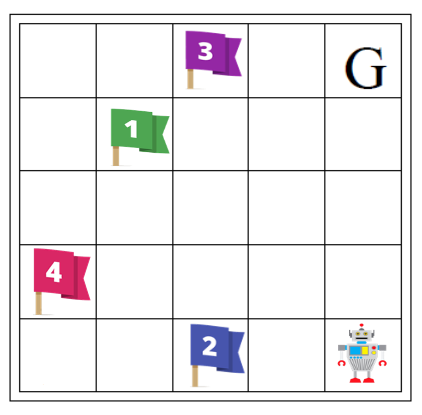



<h1><center>Figure 1: 5x5 Flags Domain</center></h1>

In each episode, the robot begins in the right lower corner. As illustrated in Figure 1, instead of a single
destination G, there are four different flags, numbered 1, 2, 3 and 4, that must be
collected in the correct order (first 1, then 2, etc... to 4). Once the robot has collected all the flags in the correct order and lands on cell G, the task is complete. If the robot collects the wrong flag at the wrong time (e.g. tries to collect 2 first, then 1...), the robot does not have to start over. Instead, the robot is penalized for taking this action, and the wrong flag is not collected (you may assume for training purposes, that the flags that have already been collected so far are kept). The main objective is to collect all the flags in the correct order in the least possible amount of time.

### 2. Problem modelling [15 Marks]

You are tasked with modelling the Flags environment. Then, you are asked to provide a programming description of the problem that will be used to solve it computationally using model-free reinforcement learning.

2.1.Answer the following questions:

(a) Define the state $(S)$ and action spaces $(A)$.[2 Marks]

**State Space**: 

State Space = $\{s_{ijk}\}$, $\forall$ $i = 0, 1, 2, 3, 4$ (row number top to down), $\forall$ $j = 0, 1, 2, 3, 4$ (col number starting from left to right), $\forall$ $k = 0, 1, 2, 3, 4$ (flag captured)

Each state is a tuple containing: (grid position (i), grid position (j), flag most recently acquired (k))

From above set, remove the following impossible states: (1, 1, 0), (4, 2, 1), (0, 2, 2), (3, 0, 3). These states are impossible becuase we assume that once the robot reaches a cell with the subsequent flag, it will capture it. Thus, it is not possible to have a state where the robot reaches a cell with the next flag, and the flag number (k) does not increase by 1.

Total number of states $= 5^3 - 4$ $= 121$

**Action Space**:

$\{l, r, u, d\}$

Corresponding to left, right, up, down respectively.

(b) Construct a reward function ($R$) that aligns with the goal(s) you want your robot to achieve. [2 Marks]

$R(s', a, s)=
\begin{cases}
    -20 - \text{ManhattanDistance between robot curr location and flag k+1 (or goal if k==4)}, & \text{if s' contains flag > k+1}, \\
    -\text{ManhattanDistance between robot curr location and flag k+1 (or goal if k==4)}, & \text{otherwise}
\end{cases}$

(c) Based on Figure 1, what is an optimal policy for this problem? You may explain your policy by drawing Figure 1 and trace the path the robot should take. Is there more than one optimal policy?[3 Marks]

There are in total 24,400 optimal policies. Each optimal policy is a combination of sub optimal policies from each sub tasks (S->F1, F1->F2, F2->F3, F3->F4, F4->G) during the entire travel (S->G). Also, each sub task has multiple optimal paths in their feasible optimal paths' space. For example, S->F1 has total 16 optimal paths, and F1->F2 has total 4 optimal paths. The final total number of optimal policy should be multiplied each sub tasks' the total number of optimal policy (16 x 4 x 1 x 10 x 35 = 22,400). 

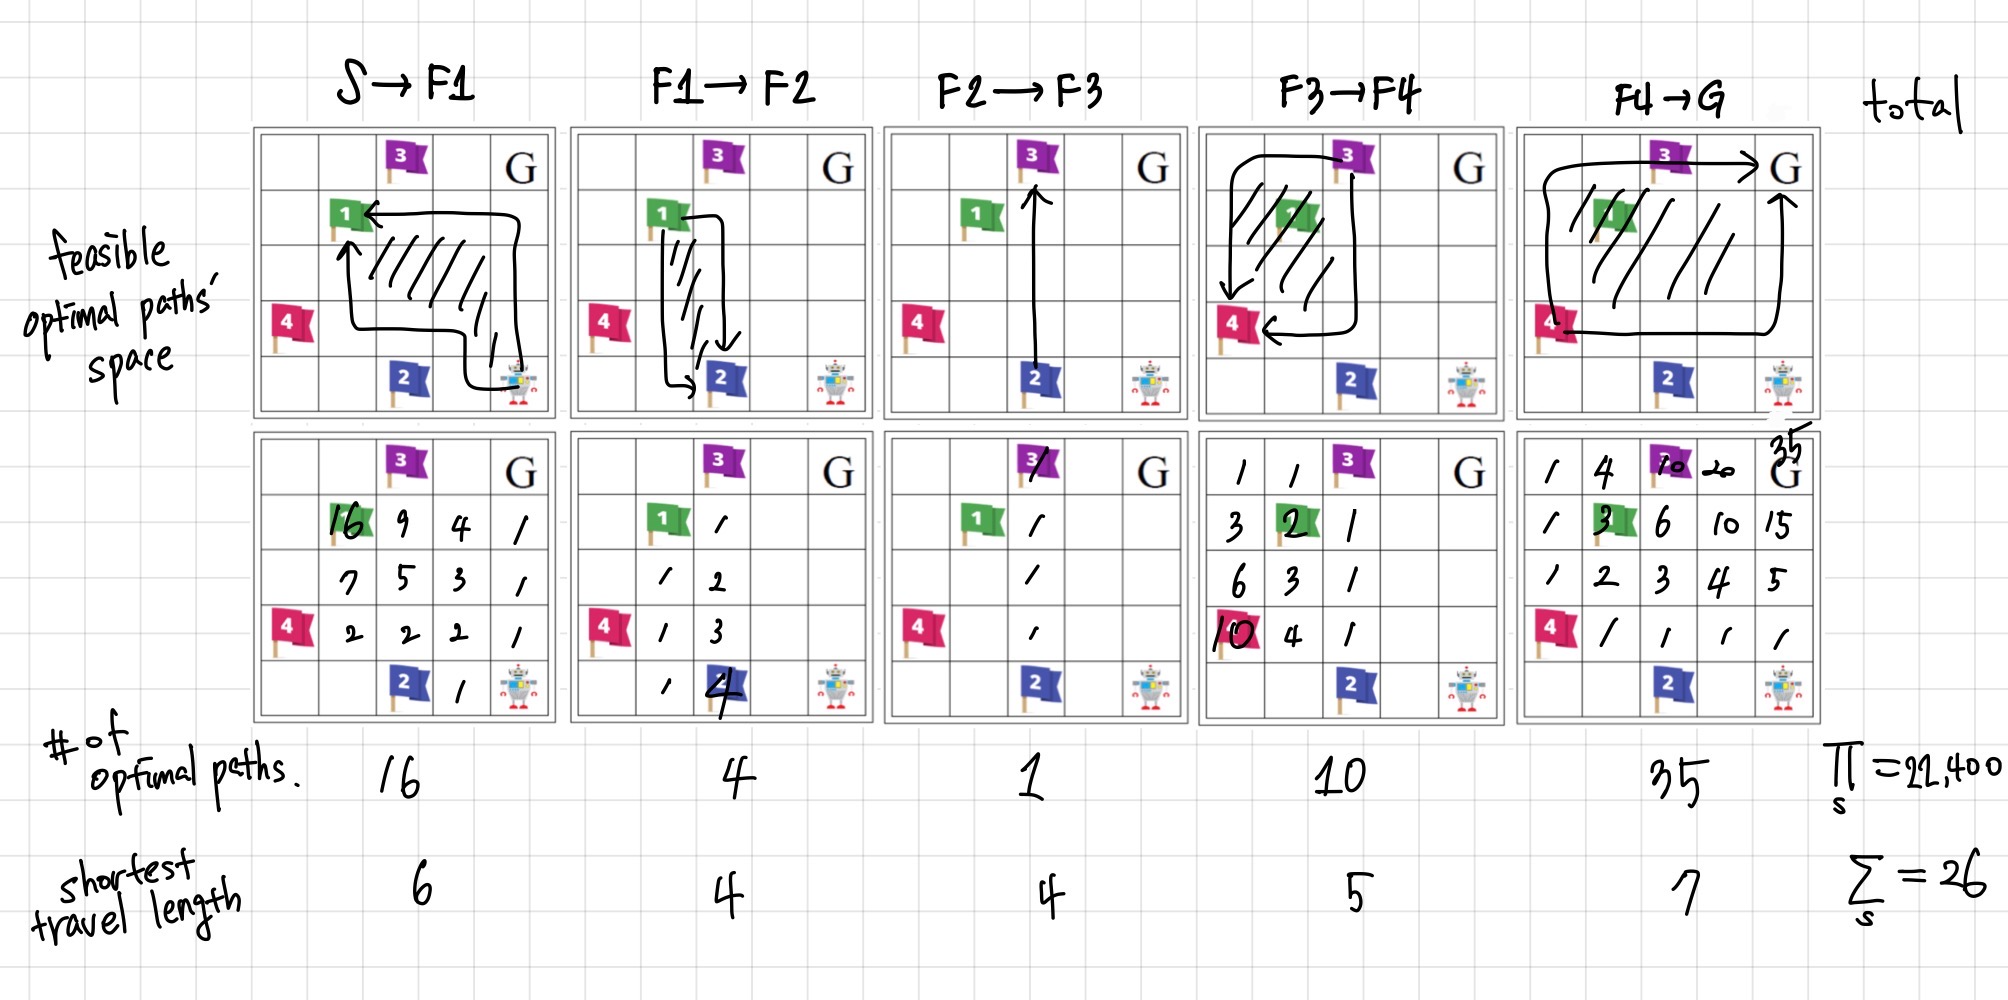


Here are three examples of optimal policy out of 22,400 drawn. All of them should take the total travel length of 26, which is the sum of each sub tasks' shortest travel path length.

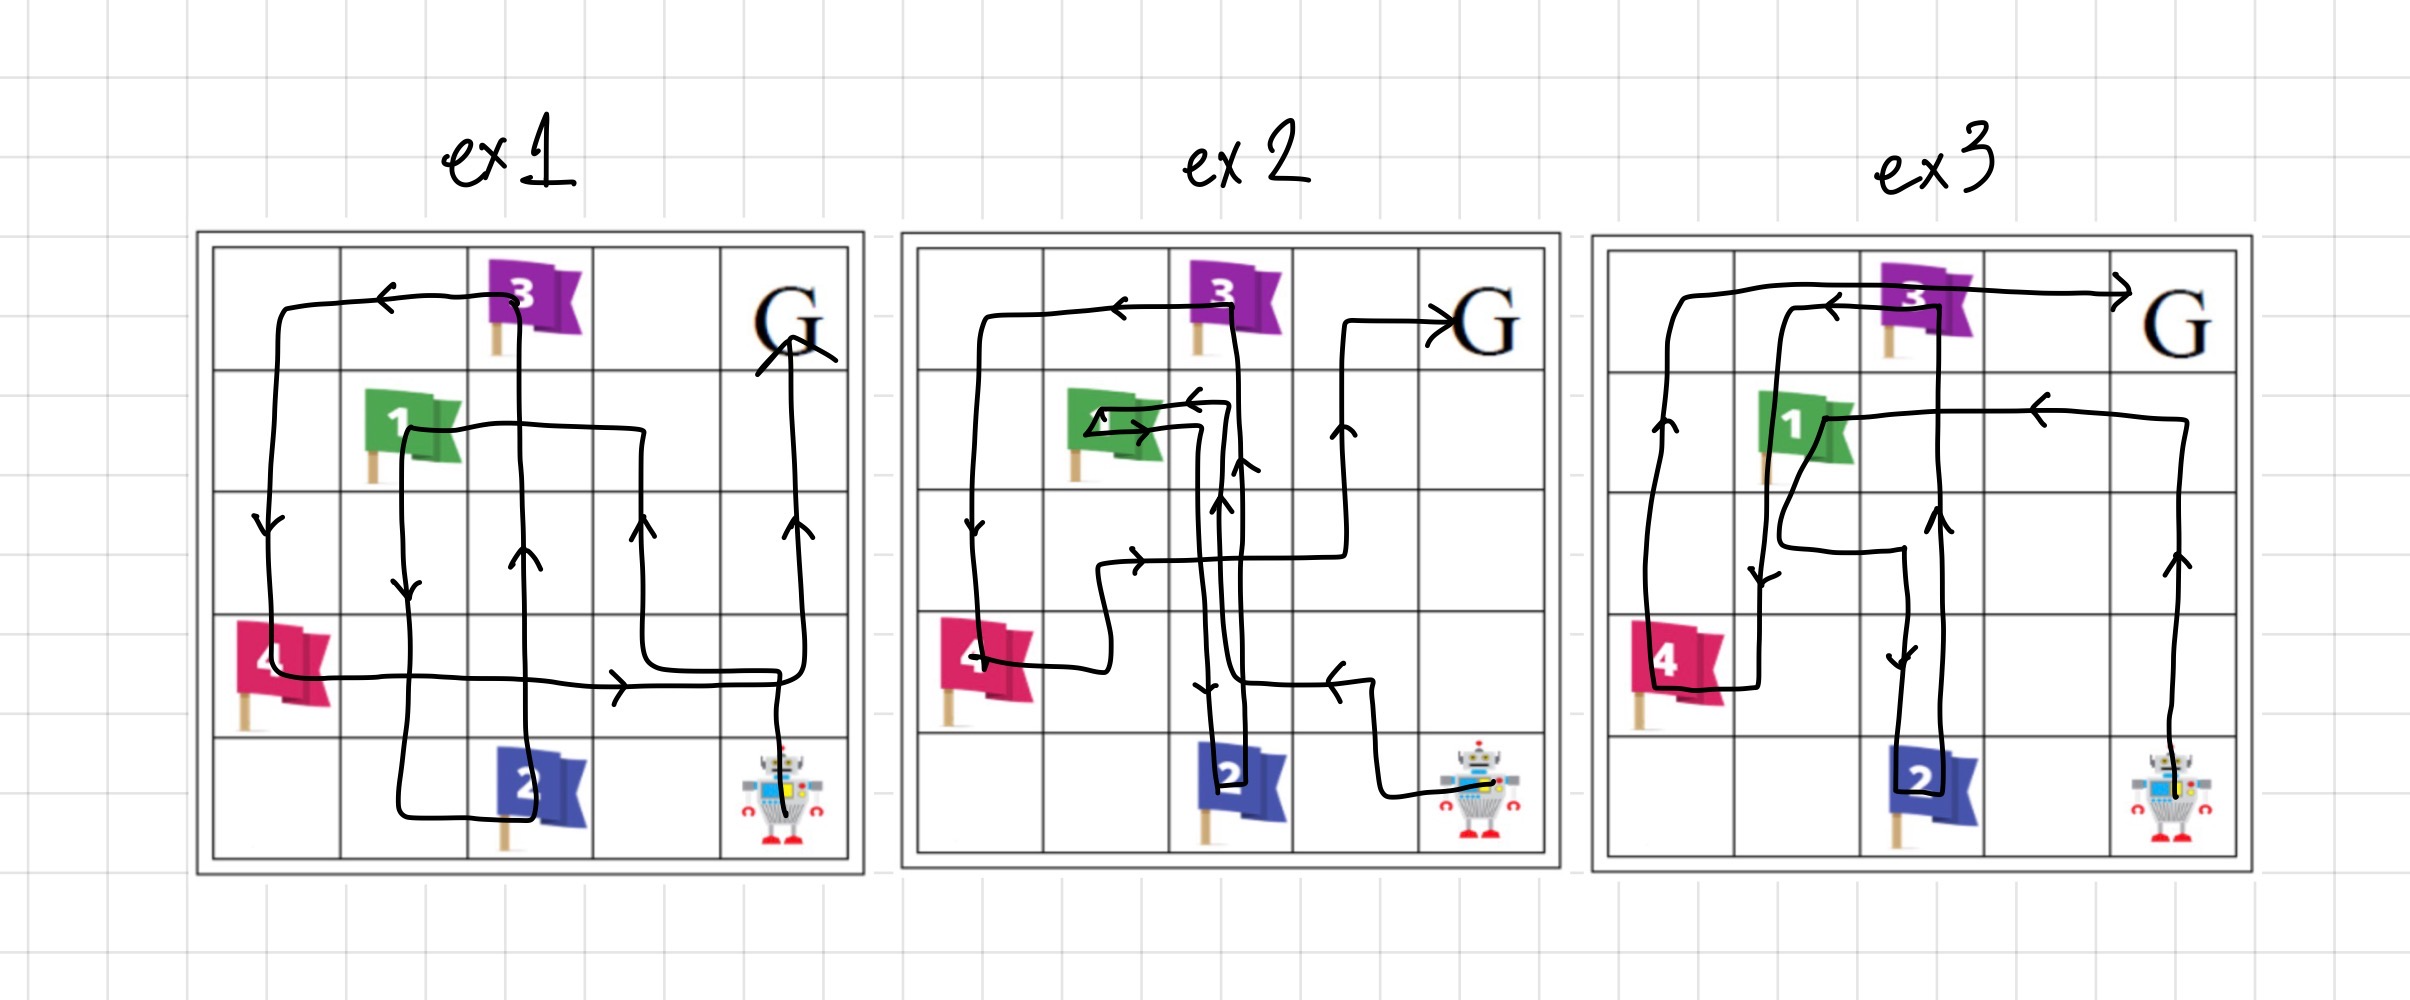

2.2 Implement the dynamics of the Flags environment. [8 Marks]

In [2]:
# imports
import random
from matplotlib import pyplot as plt

In [3]:
class Flags:
    def __init__(self):
        self.init_state = (4, 4, 0)     # state tuple (x, y, recent_flag_captured). recent_flag_captured = 0 if none captured
        self.goal_state = (0, 4, 4)     
        self.goal_loc = (0, 4)
        self.flag_locs = {1: (1, 1), 2: (4, 2), 3: (0, 2), 4: (3, 0)}
        self.loc_flags = {(1, 1): 1, (4, 2): 2, (0, 2): 3, (3, 0): 4}
        self.map_action_to_movement = {'l': (0, -1), 'r': (0, 1), 'u': (-1, 0), 'd': (1, 0)}

    # return the initial state ...
    def reset(self):
        return self.init_state

    # return a list containing all the possible states in the environment
    def states_space(self):
        # there are 4 invalid states which are not possible; (1, 1, 0), (4, 2, 1), (0, 2, 2), (3, 0, 3)
        all_states_space = [(x, y, flag) for x in range(5) for y in range(5) for flag in range(5)]
        invalid_states_space = []
        for flag, loc in self.flag_locs.items():
            invalid_states_space.append((loc[0], loc[1], flag-1))
        valid_states_space = list(set(all_states_space) - set(invalid_states_space))
        return valid_states_space
    
    # checks whether the provided grid location is within bounds
    def check_valid_loc(self, loc): 
        if not(0 <= loc[0] <= 4) or not(0 <= loc[1] <= 4):
            return False
        return True

    # return a list containing all the possible actions corresponding to the given state
    def actions_space(self, state):
        return ['l', 'r', 'u', 'd']

    # dense reward
    def reward(self, state, next_state):
        new_loc, curr_flag = next_state[:2], state[-1]
        
        # check whether the state is already goal state
        if next_state == self.goal_state:
            return 0

        penalty = 0

        # if goal cell reached too early, penalize
        if new_loc == self.goal_loc and curr_flag < 4:
            penalty = -20

        # if incorrect flag captured, penalize
        if new_loc in self.loc_flags:
            if (self.loc_flags[new_loc] > curr_flag + 1):  
                penalty = -20

        # Determine target: either the next flag or the goal if all flags are collected
        target = self.goal_loc if curr_flag == 4 else self.flag_locs[curr_flag + 1]

        # Return negative Manhattan distance + penalty
        return -1 * (abs(target[0] - new_loc[0]) + abs(target[1] - new_loc[1])) + penalty
    
    # environment transition returns s' and r.
    def transition(self, state, action):

        # if given state is already a goal state, terminate
        if state == self.goal_state:
            return self.goal_state, self.reward(state, self.goal_state)

        # get new location with given state and action
        movement = self.map_action_to_movement[action]
        new_loc, curr_flag = (state[0] + movement[0], state[1] + movement[1]), state[-1]

        if not self.check_valid_loc(new_loc): # if new_loc is out of bounds, don't move
            new_loc = state[:2]

        # get new_flag to create next_state
        if curr_flag == 4:
            new_flag = curr_flag
        else:
            if new_loc in self.loc_flags:
                flag_at_loc = self.loc_flags[new_loc]
                if flag_at_loc == curr_flag + 1: # if the new grid location has a flag and it is the next flag (correct), capture it
                    new_flag = curr_flag + 1
                else: # wrong flag or visiting an old flag
                    new_flag = curr_flag
            else: # moving to empty space without flag
                new_flag = curr_flag
        
        # get next_state
        next_state = (new_loc[0], new_loc[1], new_flag)
        
        return next_state, self.reward(state, next_state)

In [4]:
env = Flags()
env.states_space()
test_states = [
    # given valid states
    (4, 4, 0), # work swell
    (1, 2, 0), # works well
    (4, 1, 1), # works well
    (2, 1, 1), # works well
    (0, 1, 1), # works well
    (4, 0, 2), # works well
    (0, 3, 3), # works well
    (0, 3, 4), # works well

    (1, 2, 3), # works well

    # given goal state
    (0, 4, 4),
]
for state in test_states:
    rewards = []
    for action in ['l', 'r', 'u', 'd']:
        next_state, reward = env.transition(state, action)
        rewards.append(reward)
    print(f"For {state} with 4 actions, reward is {rewards}.")
    print(f"For {state} with actions is {env.actions_space(state)}.")

For (4, 4, 0) with 4 actions, reward is [-5, -6, -5, -6].
For (4, 4, 0) with actions is ['l', 'r', 'u', 'd'].
For (1, 2, 0) with 4 actions, reward is [0, -2, -22, -2].
For (1, 2, 0) with actions is ['l', 'r', 'u', 'd'].
For (4, 1, 1) with 4 actions, reward is [-2, 0, -2, -1].
For (4, 1, 1) with actions is ['l', 'r', 'u', 'd'].
For (2, 1, 1) with 4 actions, reward is [-4, -2, -4, -2].
For (2, 1, 1) with actions is ['l', 'r', 'u', 'd'].
For (0, 1, 1) with 4 actions, reward is [-6, -24, -5, -4].
For (0, 1, 1) with actions is ['l', 'r', 'u', 'd'].
For (4, 0, 2) with 4 actions, reward is [-6, -5, -25, -6].
For (4, 0, 2) with actions is ['l', 'r', 'u', 'd'].
For (0, 3, 3) with 4 actions, reward is [-5, -27, -6, -5].
For (0, 3, 3) with actions is ['l', 'r', 'u', 'd'].
For (0, 3, 4) with 4 actions, reward is [-2, 0, -1, -2].
For (0, 3, 4) with actions is ['l', 'r', 'u', 'd'].
For (1, 2, 3) with 4 actions, reward is [-3, -5, -5, -3].
For (1, 2, 3) with actions is ['l', 'r', 'u', 'd'].
For (0, 4

In [5]:
import unittest

In [6]:
class TestFlagsEnvironment(unittest.TestCase):
    def setUp(self):
        """Initialize the Flags environment for testing."""
        self.env = Flags()  # Instantiate your environment

    def test_transition_moves_correctly(self):
        """Test that normal movement updates the agent's position correctly."""
        state = (0, 0, 0)  # Start position
        action = 'r'  # Move right (assuming 'right' maps to (1,0))
        new_state, _ = self.env.transition(state, action)

        expected_state = (0, 1, 0)  # Should move right, flags unchanged
        self.assertEqual(new_state, expected_state)

    def test_transition_collects_flags_in_order(self):
        """Test that flags are collected in the correct sequence."""
        state = (1, 0, 0)  # Moving to flag 1's location
        action = 'r'  # Assuming staying still is valid for collection
        new_state, _ = self.env.transition(state, action)

        expected_state = (1, 1, 1)  # Flag 1 should be collected
        self.assertEqual(new_state, expected_state)

    def test_transition_does_not_skip_flags(self):
        """Test that flags cannot be collected out of order."""
        state = (1, 2, 1)  # Has flag 1, but flag 2 is missing
        action = 'u'  # Move to flag 3's position
        new_state, _ = self.env.transition(state, action)

        self.assertEqual(new_state, (0, 2, 1))  # Should NOT increment flag count

    def test_transition_stays_in_bounds(self):
        """Test that the agent cannot move out of bounds."""
        state = (0, 1, 0)
        action = 'u'  # Move out of bounds
        new_state, _ = self.env.transition(state, action)

        self.assertEqual(new_state, (0, 1, 0))  # Should remain unchanged

    def test_transition_reaches_goal(self):
        """Test that reaching the goal state is correctly handled."""
        goal_x, goal_y = self.env.goal_state[:2]
        state = (goal_x, goal_y-1, len(self.env.loc_flags))  # Just before goal
        action = 'r'  # Move into the goal state
        new_state, _ = self.env.transition(state, action)

        self.assertEqual(new_state, self.env.goal_state)

    def test_reward_for_normal_movement(self):
        """Test that moving normally gives the expected reward."""
        state = (0, 0, 0)
        action = 'r'
        _, reward = self.env.transition(state, action)

        expected_reward = self.env.reward(state, (1, 0, 0))
        self.assertEqual(reward, expected_reward)

    def test_reward_for_collecting_flag(self):
        """Test that capturing a flag increases the reward."""
        state = (0, 1, 0)
        action = 'd'
        _, reward = self.env.transition(state, action)

        expected_reward = self.env.reward(state, (1, 1, 1))
        self.assertEqual(reward, expected_reward)

    def test_reward_for_reaching_goal(self):
        """Test that reaching the goal state gives the maximum reward."""
        goal_x, goal_y = self.env.goal_state[:2]
        state = (goal_x, goal_y-1, len(self.env.loc_flags))
        action = 'r'
        _, reward = self.env.transition(state, action)

        expected_reward = self.env.reward(state, self.env.goal_state)
        self.assertEqual(reward, expected_reward)

if __name__ == "__main__":
    unittest.main(argv=['first-arg-is-ignored'], exit=False)


........
----------------------------------------------------------------------
Ran 8 tests in 0.013s

OK


### 3 Monte Carlo Method [35 Marks]

In this section, you are asked to implement Monte Carlo methods to solve the flags domain. Use a discount factor of
$\gamma= 0.99$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point, the episode ends.Training should proceed for a total of 2000 episodes.


3.1.Create a function $generate\_episode$ which takes as input a policy $\pi$ and the environment. This function should return the tuple of states, actions and rewards generated in an episode following $\pi$.    [5 Marks]

In [7]:
# 3.1 - Generate Episode

def generate_episode(init_state: tuple, init_action: str, policy: dict, env: Flags):
    env.reset()
    goal_state = env.goal_state
    curr_state, init_reward = env.transition(init_state, init_action)
    states, actions, rewards = [init_state], [init_action], [init_reward]
    t = 1   # since S_0, A_0, R_1 already initialized and appended to array

    while curr_state != goal_state and t < 200:
        action = random.choices(env.actions_space(curr_state), weights=policy[curr_state])[0]
        next_state, reward = env.transition(curr_state, action)
        states.append(curr_state)               # S_t
        actions.append(action)                  # A_t
        rewards.append(reward)                  # R_t+1
        curr_state = next_state
        t += 1
    
    return states, actions, rewards

In [8]:
env = Flags()
all_states = env.states_space()
policy = policy = {state: [1/len(env.actions_space(state))]*len(env.actions_space(state)) for state in all_states} # stochastic policy follows this format: {key=state: value=[prob of 'l', prob of 'r', prob of 'u', prob of 'd']}

init_state = (4, 4, 0)
init_action = 'l'

states, actions, rewards = generate_episode(init_state, init_action, policy, env)

print(states)
print(actions)
print(rewards)

[(4, 4, 0), (4, 3, 0), (3, 3, 0), (4, 3, 0), (4, 2, 0), (3, 2, 0), (2, 2, 0), (2, 1, 0), (3, 1, 0), (3, 2, 0), (4, 2, 0), (4, 3, 0), (3, 3, 0), (3, 2, 0), (4, 2, 0), (4, 2, 0), (3, 2, 0), (2, 2, 0), (2, 1, 0), (3, 1, 0), (2, 1, 0), (2, 2, 0), (2, 3, 0), (2, 2, 0), (2, 3, 0), (3, 3, 0), (4, 3, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (3, 4, 0), (4, 4, 0), (4, 4, 0), (3, 4, 0), (2, 4, 0), (2, 4, 0), (3, 4, 0), (3, 4, 0), (4, 4, 0), (4, 4, 0), (4, 3, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (4, 3, 0), (4, 2, 0), (3, 2, 0), (2, 2, 0), (3, 2, 0), (4, 2, 0), (3, 2, 0), (4, 2, 0), (3, 2, 0), (4, 2, 0), (4, 1, 0), (4, 0, 0), (4, 0, 0), (4, 0, 0), (4, 0, 0), (4, 1, 0), (4, 0, 0), (4, 0, 0), (4, 0, 0), (4, 1, 0), (3, 1, 0), (4, 1, 0), (4, 1, 0), (4, 2, 0), (4, 2, 0), (4, 2, 0), (4, 3, 0), (4, 2, 0), (4, 3, 0), (4, 3, 0), (4, 3, 0), (4, 4, 0), (4, 3, 0), (4, 2, 0), (4, 3, 0), (4, 3, 0), (4, 3, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (4, 4, 0), (3, 4, 0)

3.2.Implement the first-visit Monte Carlo (for $\epsilon$-soft policies) control algorithm to find the approximate optimal
policy $\pi^*$. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and include plots in your report for each of these values. What is the best value of $\epsilon$? Why? For each $\epsilon$, did your algorithm converge at all? What was the final policy and
Q-values that you typically obtain (typically, as in the majority of the trials)? Does this correspond to an optimal policy? Visualize the learning process (for instance, change in Q for some state; or any other visualization) to support your claims.  [15 Marks]

In [9]:
# 3.2 - Plotting helper function

def create_plots(env, q, policy, epsilon=None, sampling_type=None, epoch=2000):

    # plot the q values for each state
    fig1, axis1 = plt.subplots(1, 5, figsize=(50, 10))
    if sampling_type:
        fig1.suptitle(f"Graph of Q values for each flag state-action pair for every episode (type = {sampling_type})", fontsize=20)
    else:
        fig1.suptitle(f"Graph of Q values for each flag state-action pair for every episode (epsilon = {epsilon})", fontsize=20)

    for i, state in enumerate([(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]):
        for action in env.actions_space(state):
            axis1[i].plot(range(epoch), q[(state, action)], label=f"{action}")
        axis1[i].set_xlabel('Episode', fontsize=20)
        axis1[i].set_ylabel('Q', fontsize=20)
        axis1[i].set_xticks(range(0, epoch, 500), range(0, epoch, 500))
        axis1[i].set_title(f'State = {state}', fontsize=20)
        axis1[i].tick_params(axis='both', labelsize=20)
        axis1[i].legend(fontsize=20)

    # plot the policy values for each action for each state
    fig2, axis2 = plt.subplots(1, 5, figsize=(50, 10))
    if sampling_type:
        fig2.suptitle(f"Graph of policy values for each action for each flag state for every episode (type = {sampling_type})", fontsize=20)
    else:
        fig2.suptitle(f"Graph of policy values for each action for each flag state for every episode (epsilon = {epsilon})", fontsize=20)

    for i, state in enumerate([(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]):
        for action in env.actions_space(state):
            axis2[i].plot(range(epoch), policy[(state, action)], label=f"{action}")
        axis2[i].set_xlabel('Episode', fontsize=20)
        axis2[i].set_ylabel('Probability based on policy', fontsize=20)
        axis2[i].set_xticks(range(0, epoch, 500), range(0, epoch, 500))
        axis2[i].set_title(f'State = {state}', fontsize=20)
        axis2[i].tick_params(axis='both', labelsize=20)
        axis2[i].legend(fontsize=20)


def follow_policy(env: Flags, policy, off_policy=False):
    curr_state = env.init_state
    goal_state = env.goal_state
    visited = []
    path_length = 0

    while curr_state != goal_state and curr_state not in visited:

        if off_policy:
            best_action = policy[curr_state]
        else:
            max_prob = max(policy[curr_state])
            best_action = 'l'
            for i, action in enumerate(env.actions_space(curr_state)):
                if abs(policy[curr_state][i] - max_prob) < 1e-6:
                    best_action = action
                
        visited.append(curr_state)
        curr_state, _ = env.transition(curr_state, best_action)
        path_length += 1

    
    print(visited)
    print(f"Total path length of policy:{path_length}")
    if curr_state == goal_state:
        print("GOAL REACHED!")
    else:
        print("Policy not complete")

   

In [10]:
# 3.2 - First Visit Monte Carlo

def first_visit_mc(epsilon: float, env: Flags):
    gamma = 0.99
    all_states = env.states_space()

    # initialize stochastic policy as equiprobable for all actions
    policy = {state: [1/len(env.actions_space(state))]*len(env.actions_space(state)) for state in all_states} # stochastic policy follows this format: {key=state: value=[prob of 'l', prob of 'r', prob of 'u', prob of 'd']}
    q = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    returns = {(state, action): [] for state in all_states for action in env.actions_space(state)} 

    # storing values for plotting
    monitoring_states = [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]
    graph_q_values = {}
    graph_policy = {}
    
    for k in range(2000):
        # choose a random state
        rand_state = random.choice(all_states)

        # choose a random action based on the policy of the random state
        rand_action = random.choices(env.actions_space(rand_state), weights=policy[rand_state])[0]

        # generate episode for the chosen state and action
        state_ep, action_ep, reward_ep = generate_episode(rand_state, rand_action, policy, env)
        pairs = [(state_ep[i], action_ep[i]) for i in range(len(state_ep))]
        g = 0
        for t in range(len(state_ep)-1, -1, -1):
            curr_state, curr_action = state_ep[t], action_ep[t]
            prev_pairs = set(pairs[:t])
            g = (gamma * g) + reward_ep[t]

            # if first visit
            if (curr_state, curr_action) not in prev_pairs:
                returns[(curr_state, curr_action)].append(g)
                q[(curr_state, curr_action)] = sum(returns[(curr_state, curr_action)]) / len(returns[(curr_state, curr_action)])

                # find argmax_a [Q(S,a)]
                best_q = float("-inf")
                for action in env.actions_space(curr_state):
                    if q[(curr_state, action)] > best_q:
                        a_star = action
                        best_q = q[(curr_state, action)]
                
                for i, action in enumerate(env.actions_space(curr_state)):
                    # update policy by indexing actions (since action array is in order: ['l', 'r', 'u', 'd'])
                    policy[curr_state][i] = 1 - epsilon + (epsilon / len(env.actions_space(curr_state))) if action == a_star else epsilon / len(env.actions_space(curr_state))

        # for graphing
        for state in monitoring_states:
            for i, action in enumerate(env.actions_space(state)):
                if (state, action) not in graph_q_values:
                    graph_q_values[(state, action)] = [q[(state, action)]]
                else:
                    graph_q_values[(state, action)].append(q[(state, action)])
                
                if (state, action) not in graph_policy:
                    graph_policy[(state, action)] = [policy[state][i]]
                else:
                    graph_policy[(state, action)].append(policy[state][i])

    create_plots(env, graph_q_values, graph_policy, epsilon=epsilon, epoch=2000)
            
    return policy, q


Epsilon = 0.01
Policy: {(2, 0, 2): [0.0025, 0.9924999999999999, 0.0025, 0.0025], (4, 0, 4): [0.0025, 0.9924999999999999, 0.0025, 0.0025], (0, 1, 0): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (4, 0, 1): [0.0025, 0.9924999999999999, 0.0025, 0.0025], (2, 1, 3): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 3, 3): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (4, 4, 4): [0.0025, 0.0025, 0.9924999999999999, 0.0025], (3, 2, 1): [0.0025, 0.9924999999999999, 0.0025, 0.0025], (1, 3, 3): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (1, 4, 2): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (1, 3, 0): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (3, 4, 4): [0.0025, 0.0025, 0.9924999999999999, 0.0025], (3, 3, 2): [0.0025, 0.9924999999999999, 0.0025, 0.0025], (0, 0, 1): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (4, 1, 2): [0.0025, 0.0025, 0.9924999999999999, 0.0025], (1, 0, 1): [0.0025, 0.0025, 0.0025, 0.9924999999999999], (2, 3, 3): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 2, 

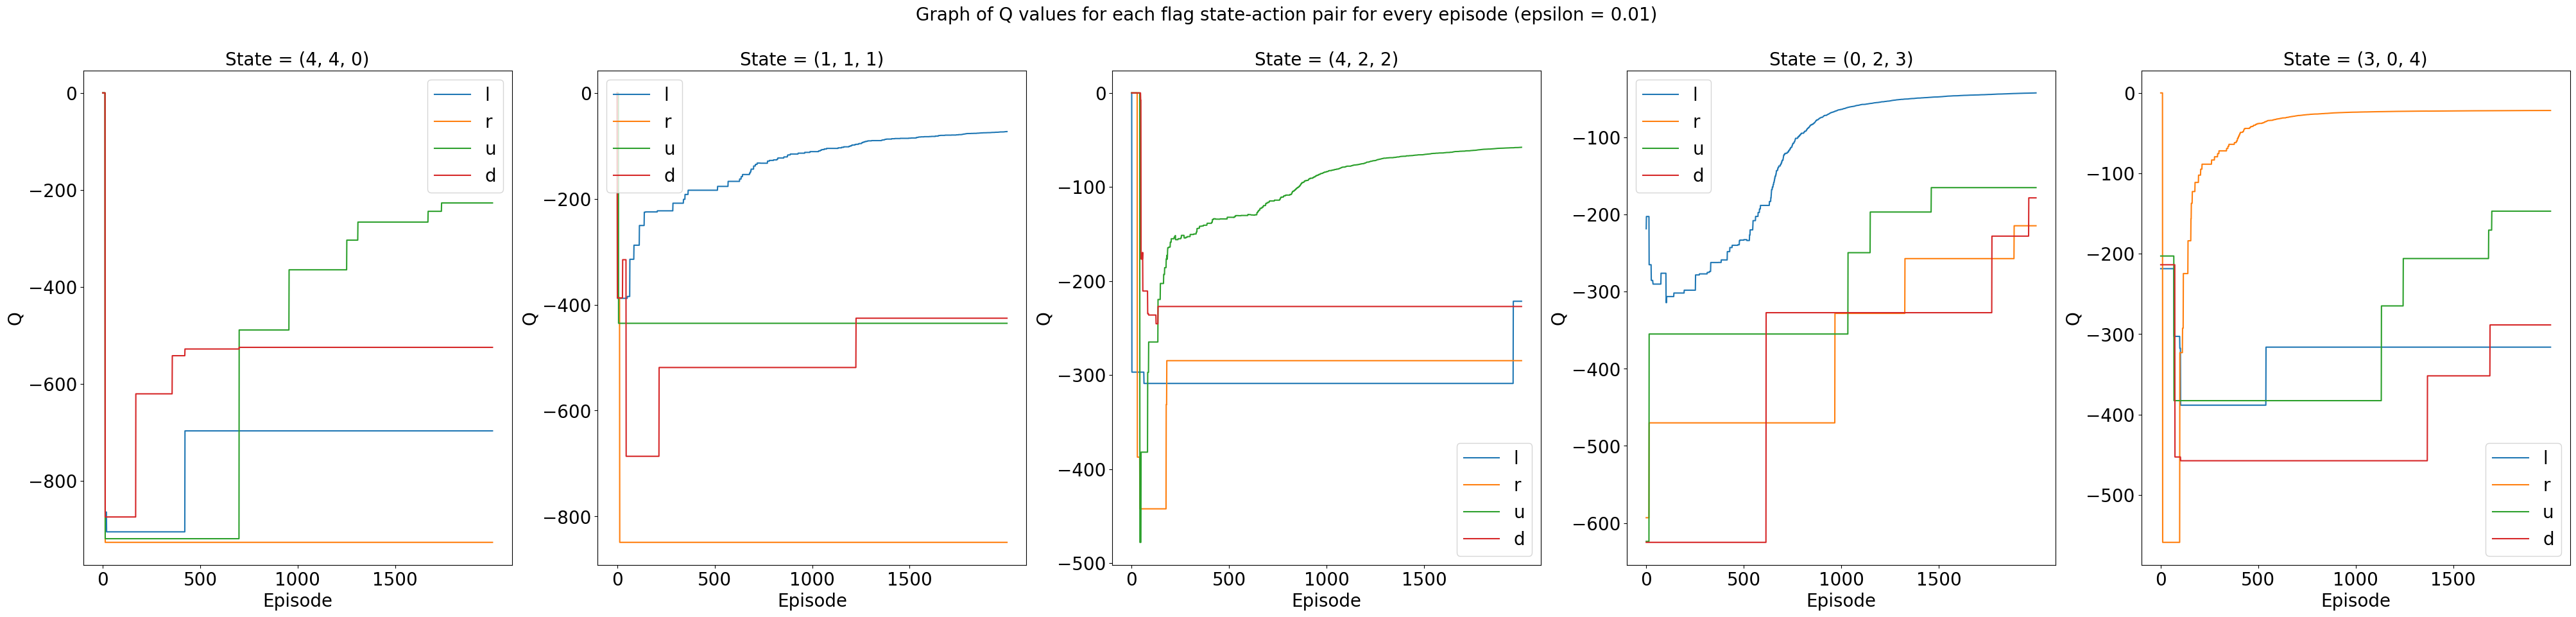

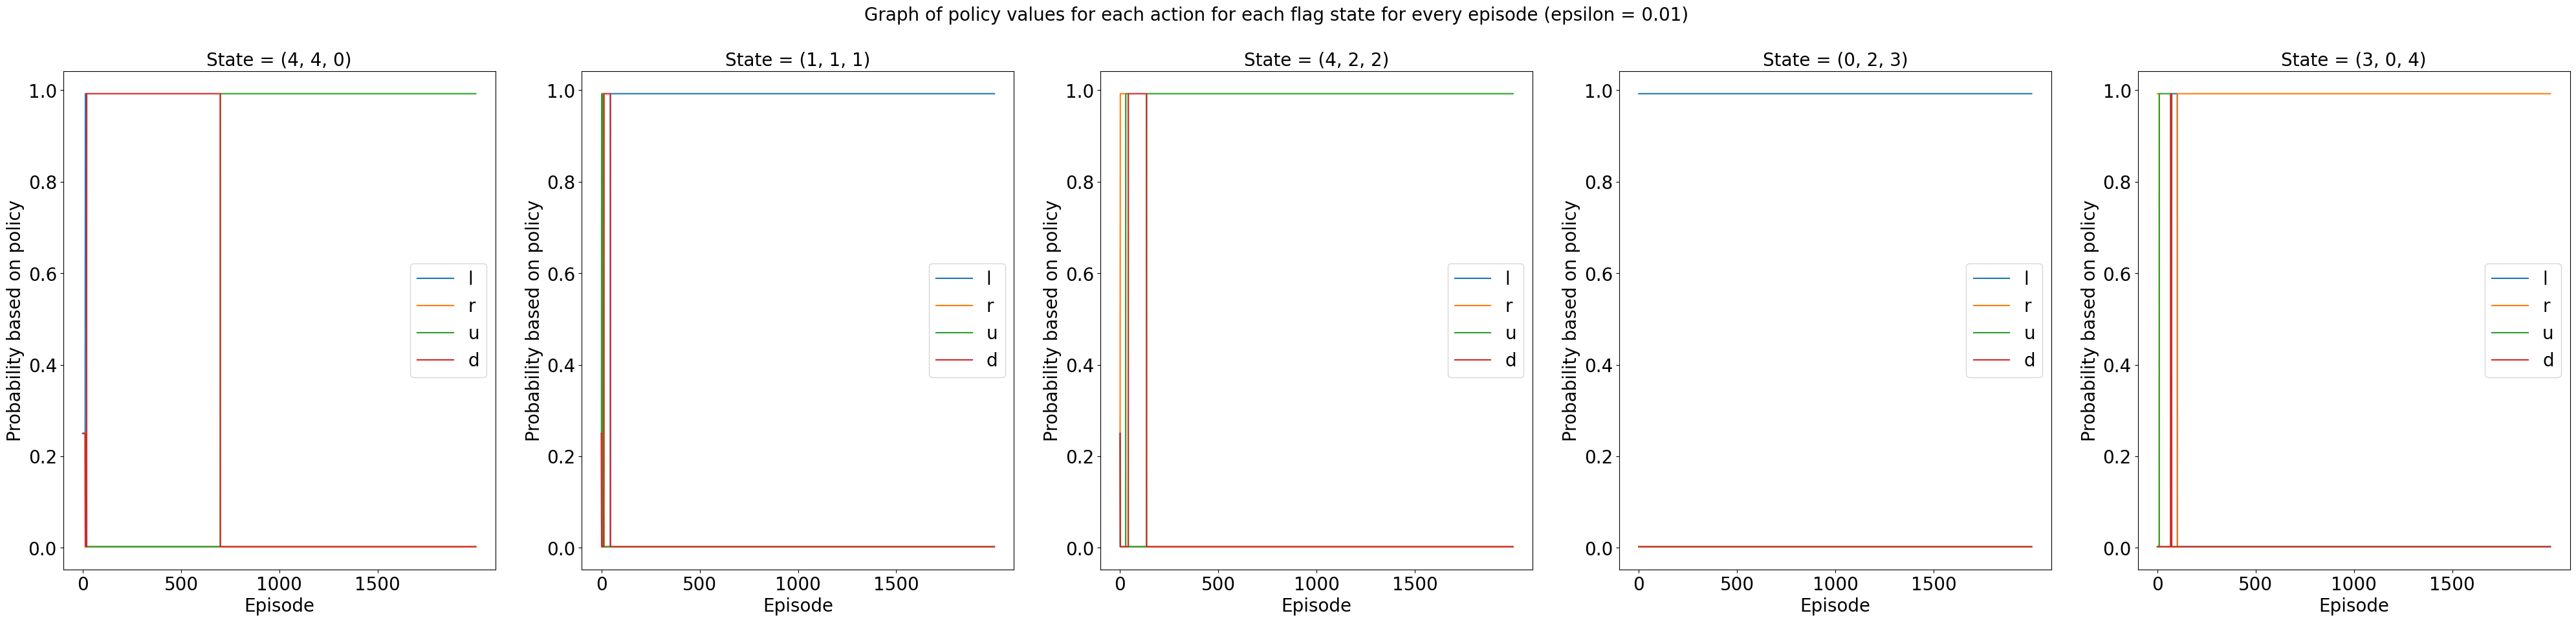

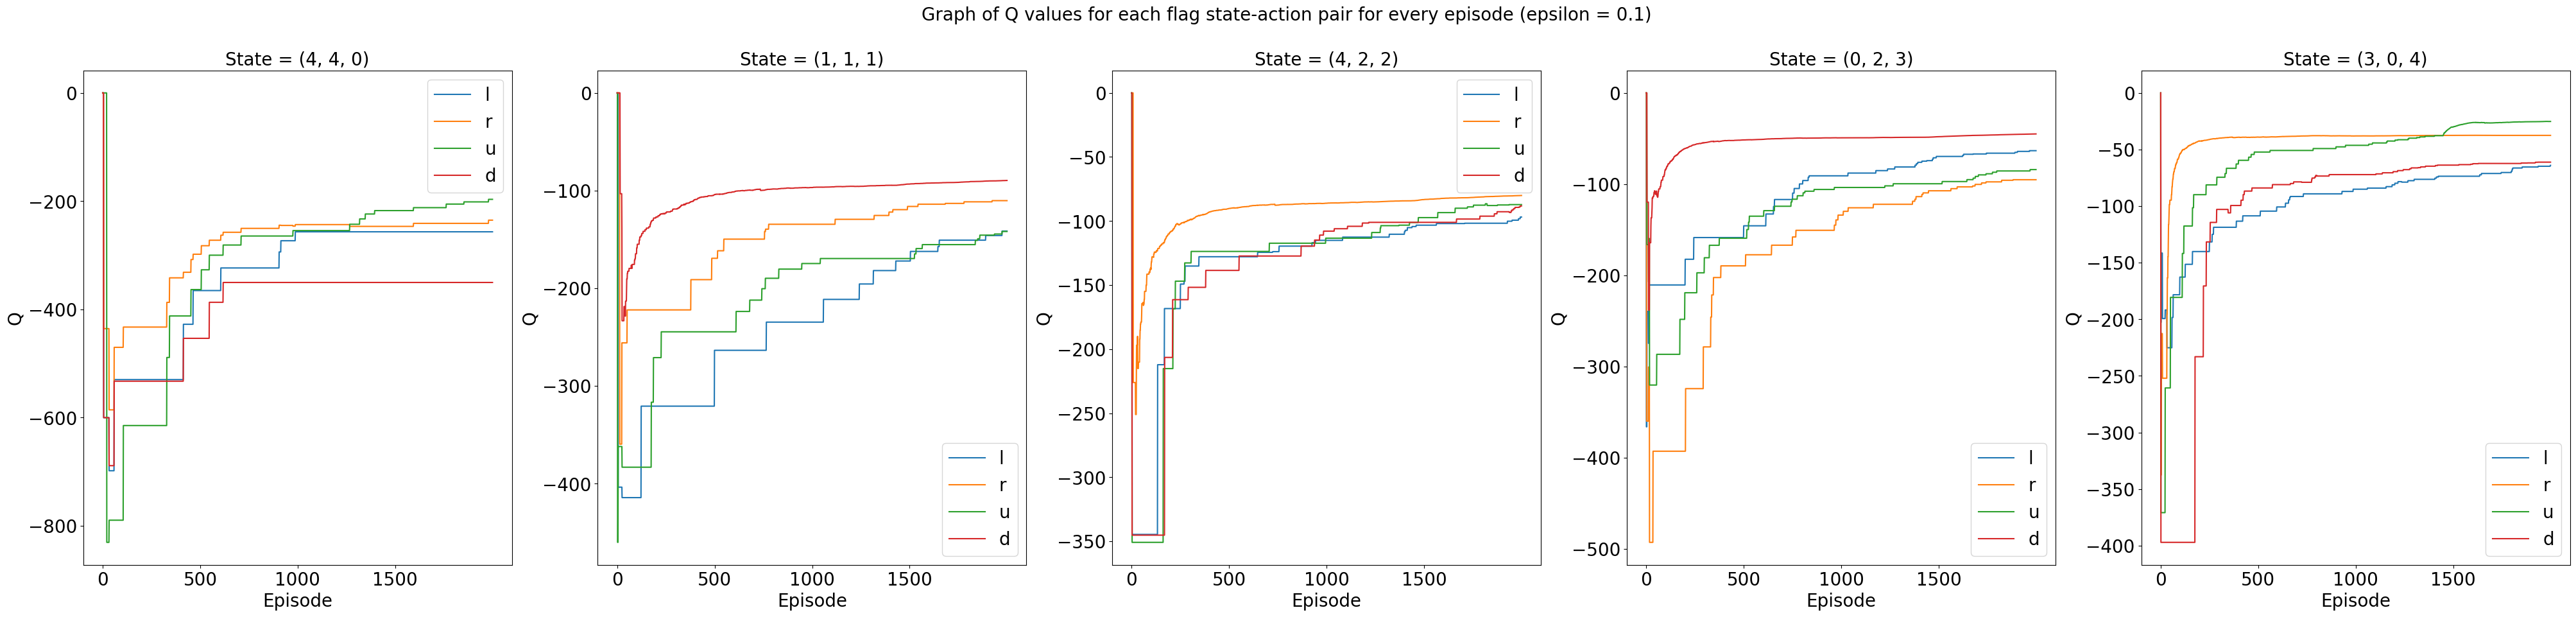

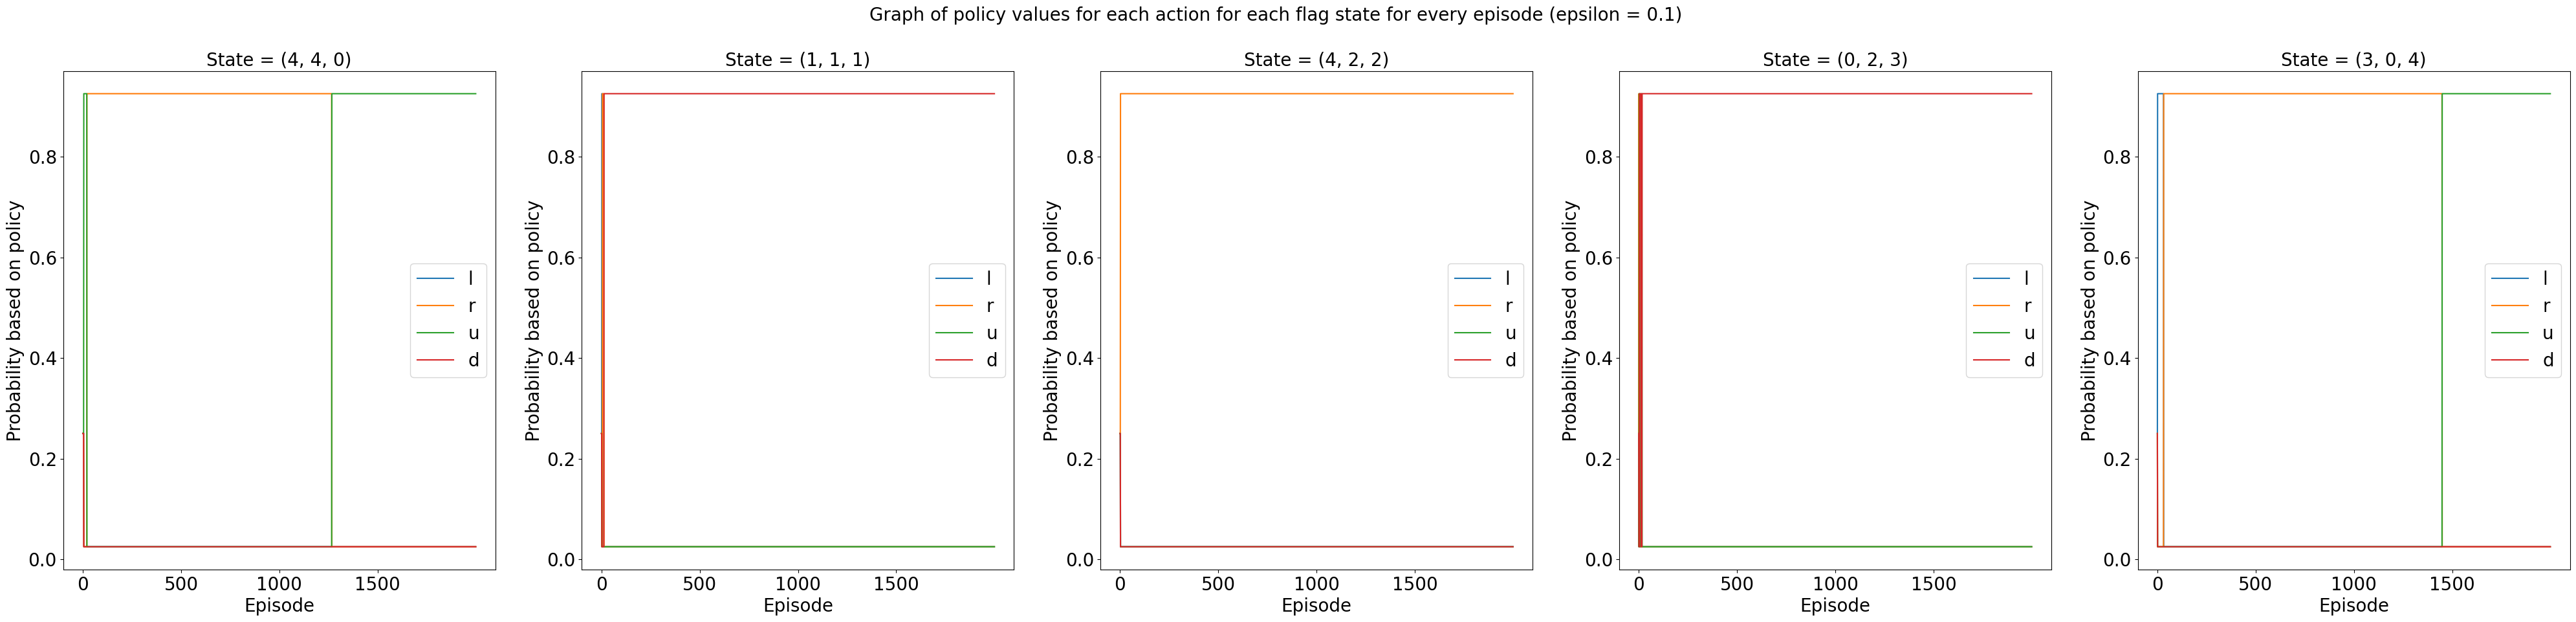

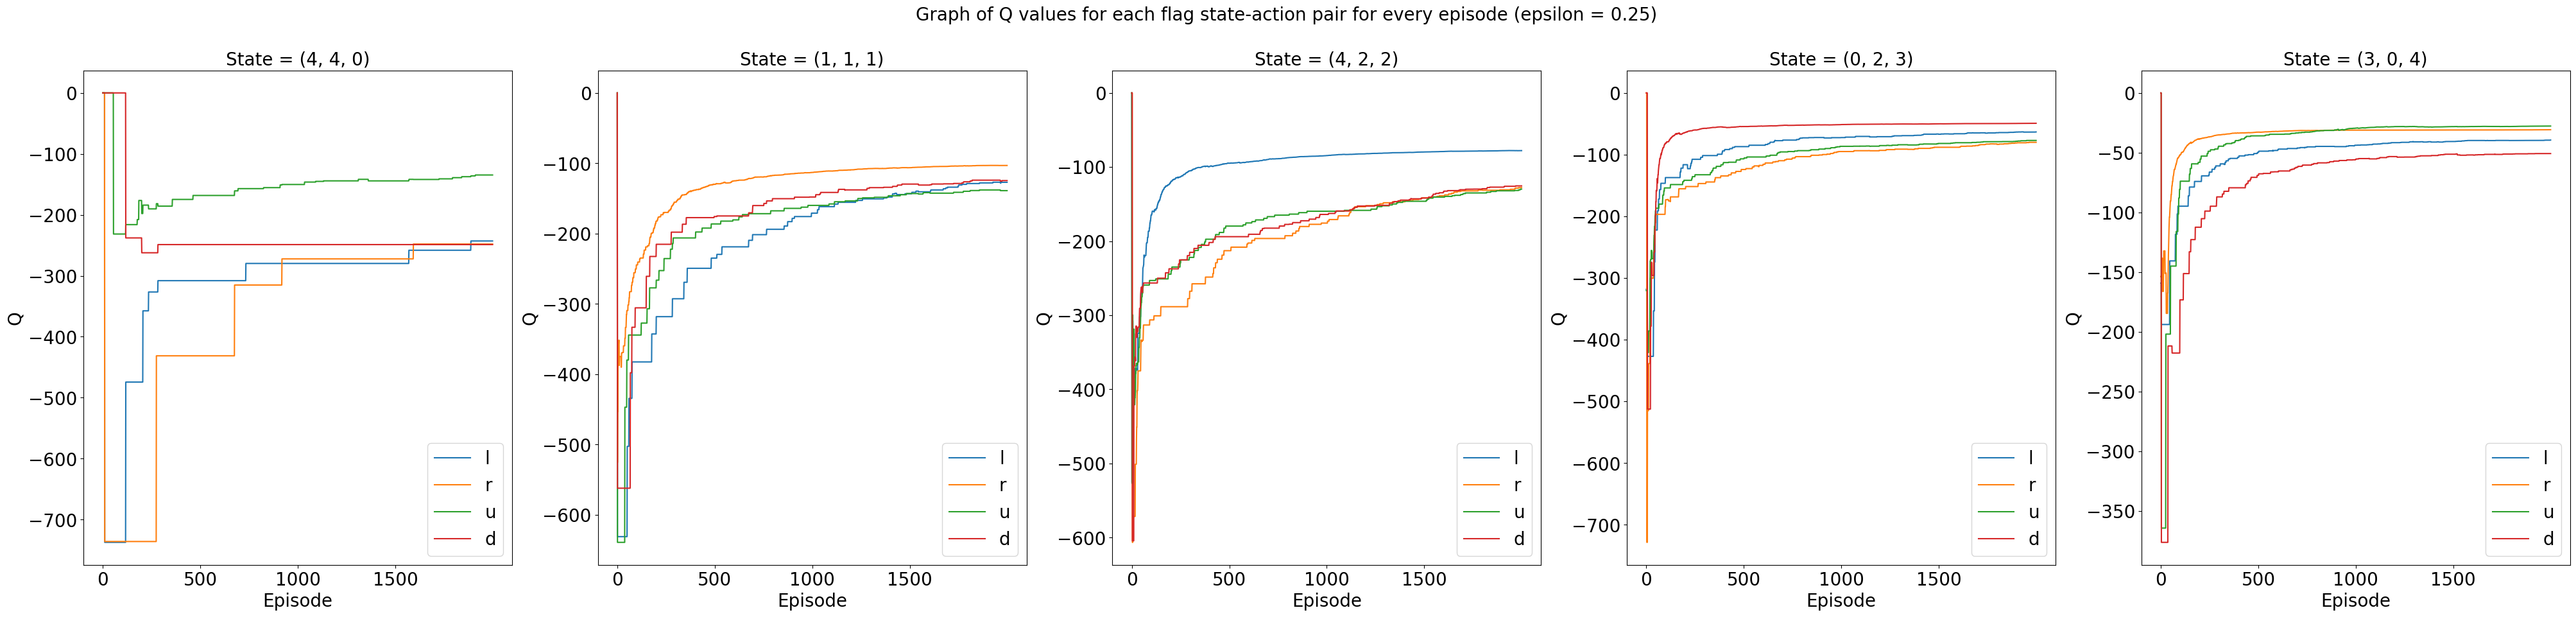

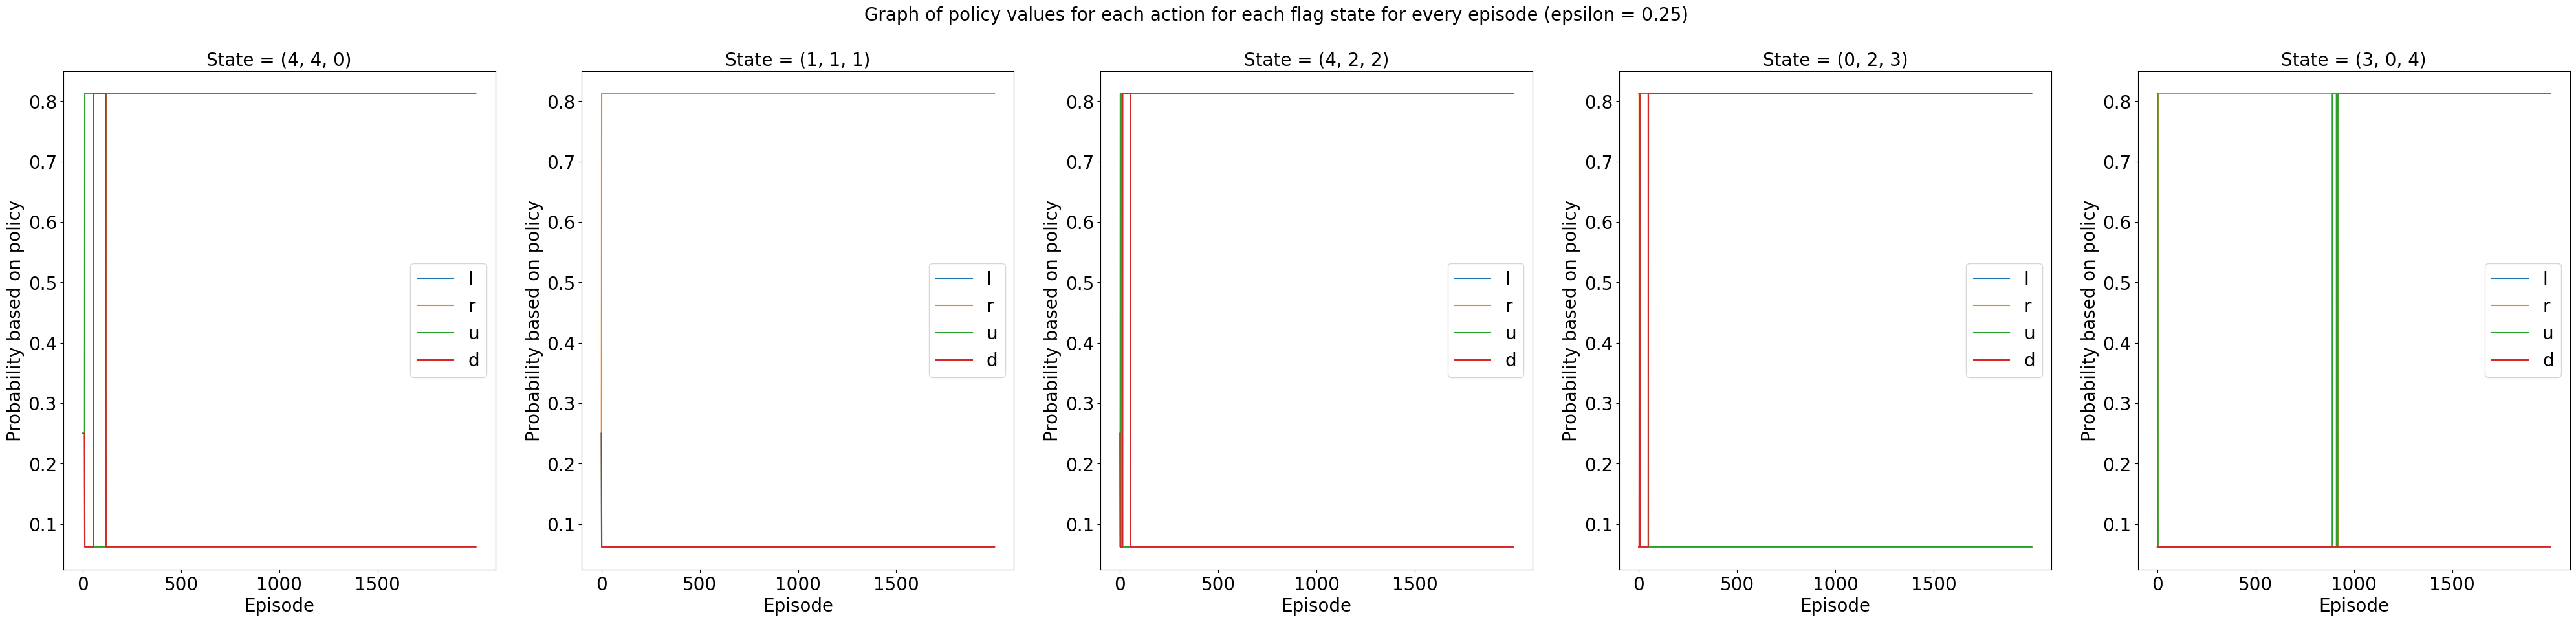

In [11]:
env = Flags()

for epsilon in (0.01, 0.1, 0.25):
    pi, q = first_visit_mc(epsilon, env)
    print(f"Epsilon = {epsilon}")
    print(f"Policy: {pi}")
    print(pi[(4, 4, 0)])
    print(f"Q: {q}")
    follow_policy(env, pi)
    print()

What is the best epsilon and why?
For each epsilon, did it converge at all? -> talk about the distribution of pi for each state
What was the pi/v for each state after 2000 episodes? (pretty print)
Describe if each correspond to an optimal policy

---See above for questions to address---

The plots for the Q values (state-action value function) and policy for 5 states are shown above. The 5 states are chosen such that they denote the initial state, and the state where a flag is captured.

Given that the epsilon value denotes the greediness of the policy, we can determine the "best" epsilon by assessing the convergence of Q. Since epsilon determines the policy of each state, one can assess how well the Q-function is evaluated for each policy to find the best epsilon. From the Q-graphs, the epsilon value that showed the fastest convergence of Q for all 5 states is epsilon = 0.25. As evident in the graphs, for epsilon = 0.25, the Q-values converge and do not flunctuate too drastically after around 1200 episodes. Also, epsilon = 0.25 reaches the goal state in the shortest path in most instances.

In terms of algorithm convergence, we can assess the convergence of Q values:

- For Epsilon = 0.01, even near the end of the 2000 episodes, it is evident that the Q values are flunctuating and certain Q(s, a) combinations are not converging. For example, for state (3, 0, 4), the actions left, up, and down show continuosly growing Q values.
    
- For Epsilon = 0.1, the Q values seem to be converging better. After 1500 episodes, the Q values do not have drastic changes and seem to be oscillating only slightly. 

- For Epsilon = 0.25, the Q values show the best convergence. For certain states, the Q values converge after 1000 episodes, and are nearly linear at the end of the 2000 episodes. 

Please see the print statements above the graph for the policy and state-value function (Q) evaluation after 2000 episodes.

In terms of completeness, all 3 epsilon values result in the robot reaching the goal state, so they are all complete. 

In terms of optimality, althought the Q values converge, the total length of the path is larger than 26 - thus it is not optimal. However, it is evident that it is close to optimality as it ranges between 26 to 36.

- For Epsilon = 0.01, within 30 - 40 range.

- For Epsilon = 0.1, within 30 - 40 range.

- For Epsilon = 0.25, within 26 - 35 range, which has the shortest.



3.3.Consider a random behavior policy $b(a|s)=1/|A|$ for every state and action. Use episodes generated with $b$ to find the approximate optimal policy $\pi^*$. First use ordinary importance sampling Monte Carlo control. Then use weighted importance sampling Monte Carlo control. Answer the same questions as in 3.2.  [15 Marks]

In [12]:
# 3.3 - Off-policy Monte Carlo

def off_policy_mc(ratio_type: str, env: Flags):
    if ratio_type not in ["WIS", "OIS"]:
        raise ValueError("Invalid Importance Sampling Type. Please enter 'WIS' for weighted or 'OIS' for ordinary")
    
    gamma = 0.99
    all_states = env.states_space()

    # initialize
    policy = {state: 'l' for state in all_states} # deterministic policy since initialized as argmax
    q = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    c = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    b = {state: [1/len(env.actions_space(state))]*len(env.actions_space(state)) for state in all_states} # behaviour policy

    # storing values for plotting
    monitoring_states = [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]
    graph_q_values = {}
    graph_policy = {}

    k = 2000

    for _ in range(k):
        # choose a random state
        rand_state = random.choice(all_states)

        # choose a random action based on the behaviour policy of the random state
        rand_action = random.choices(env.actions_space(rand_state), weights=b[rand_state])[0]

        # generate episode using behaviour policy
        state_ep, action_ep, reward_ep = generate_episode(rand_state, rand_action, b, env)
        g = 0
        w = 1
        for t in range(len(state_ep)-1, -1, -1):
            curr_state, curr_action = state_ep[t], action_ep[t]
            g = (gamma * g) + reward_ep[t]
            c[(curr_state, curr_action)] = c[(curr_state, curr_action)] + w if ratio_type == "WIS" else c[(curr_state, curr_action)] + 1
            q[(curr_state, curr_action)] = q[(curr_state, curr_action)] + ((w / c[(curr_state, curr_action)]) * (g - q[(curr_state, curr_action)])) if ratio_type == "WIS" \
                else q[(curr_state, curr_action)] + ((1 / c[(curr_state, curr_action)]) * (w*g - q[(curr_state, curr_action)]))
            
            best_q, best_action = float("-inf"), policy[curr_state]
            for action in env.actions_space(curr_state):
                if q[(curr_state, action)] > best_q:
                    best_q = q[(curr_state, action)]
                    best_action = action

            policy[curr_state] = best_action

            if curr_action != best_action:
                break

            action_index = env.actions_space(curr_state).index(curr_action)
            w = w / (b[curr_state][action_index])

        # for graphing
        for state in monitoring_states:
            for i, action in enumerate(env.actions_space(state)):
                if (state, action) not in graph_q_values:
                    graph_q_values[(state, action)] = [q[(state, action)]]
                else:
                    graph_q_values[(state, action)].append(q[(state, action)])
                
                if (state, action) not in graph_policy:
                    graph_policy[(state, action)] = [policy[state]]
                else:
                    graph_policy[(state, action)].append(policy[state])
    
    create_plots(env, graph_q_values, graph_policy, sampling_type=ratio_type, epoch=k)

    return policy, q


Type = WIS
Policy: {(2, 0, 2): 'u', (4, 0, 4): 'u', (0, 1, 0): 'l', (4, 0, 1): 'r', (2, 1, 3): 'l', (0, 3, 3): 'l', (4, 4, 4): 'u', (3, 2, 1): 'l', (1, 3, 3): 'd', (1, 4, 2): 'l', (1, 3, 0): 'l', (3, 4, 4): 'u', (3, 3, 2): 'l', (0, 0, 1): 'r', (4, 1, 2): 'd', (1, 0, 1): 'r', (2, 3, 3): 'l', (0, 2, 4): 'r', (0, 4, 1): 'l', (3, 0, 0): 'l', (2, 0, 1): 'l', (4, 0, 3): 'l', (4, 2, 0): 'l', (0, 3, 2): 'l', (4, 4, 3): 'l', (3, 1, 1): 'r', (3, 2, 0): 'l', (1, 4, 4): 'l', (1, 3, 2): 'l', (3, 3, 4): 'u', (0, 0, 3): 'd', (4, 1, 4): 'u', (4, 3, 1): 'l', (0, 0, 0): 'l', (0, 2, 0): 'l', (4, 1, 1): 'l', (1, 1, 2): 'r', (1, 0, 0): 'l', (2, 4, 4): 'u', (0, 4, 3): 'l', (3, 0, 2): 'r', (2, 0, 3): 'l', (2, 2, 0): 'l', (0, 1, 1): 'l', (4, 2, 2): 'u', (1, 2, 0): 'l', (0, 3, 4): 'r', (3, 1, 3): 'l', (3, 2, 2): 'u', (3, 1, 0): 'l', (1, 3, 4): 'r', (1, 4, 3): 'l', (2, 4, 0): 'l', (0, 0, 2): 'l', (4, 1, 3): 'd', (4, 3, 0): 'l', (1, 1, 4): 'r', (1, 0, 2): 'r', (1, 1, 1): 'l', (3, 0, 4): 'u', (2, 2, 2): 'r', (2, 

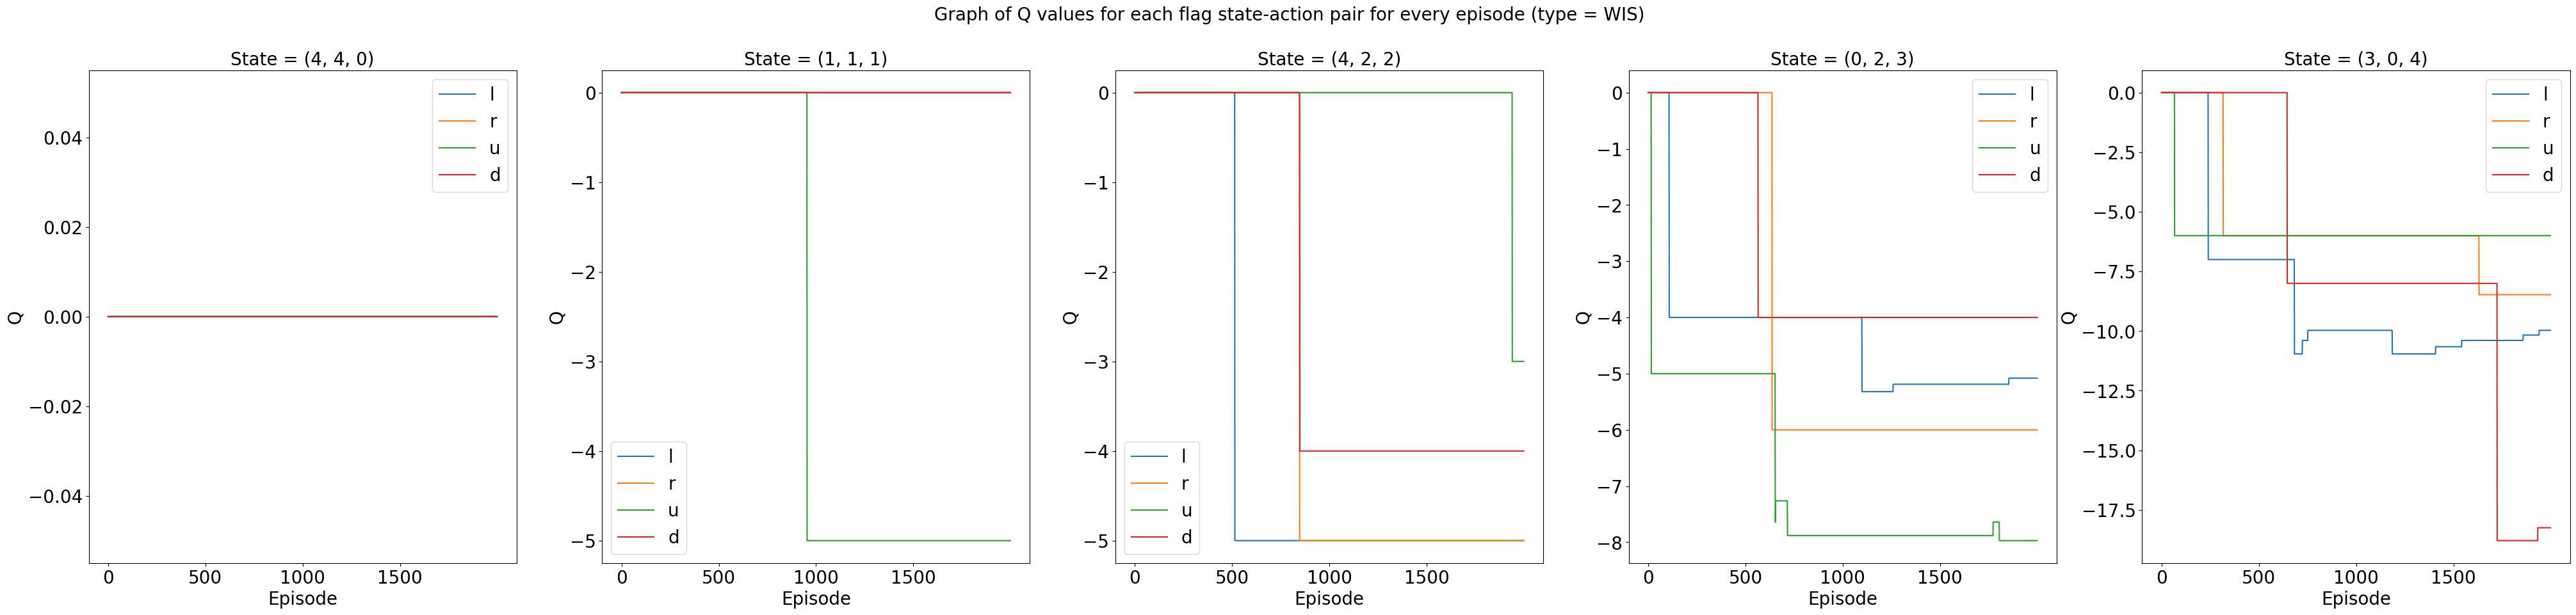

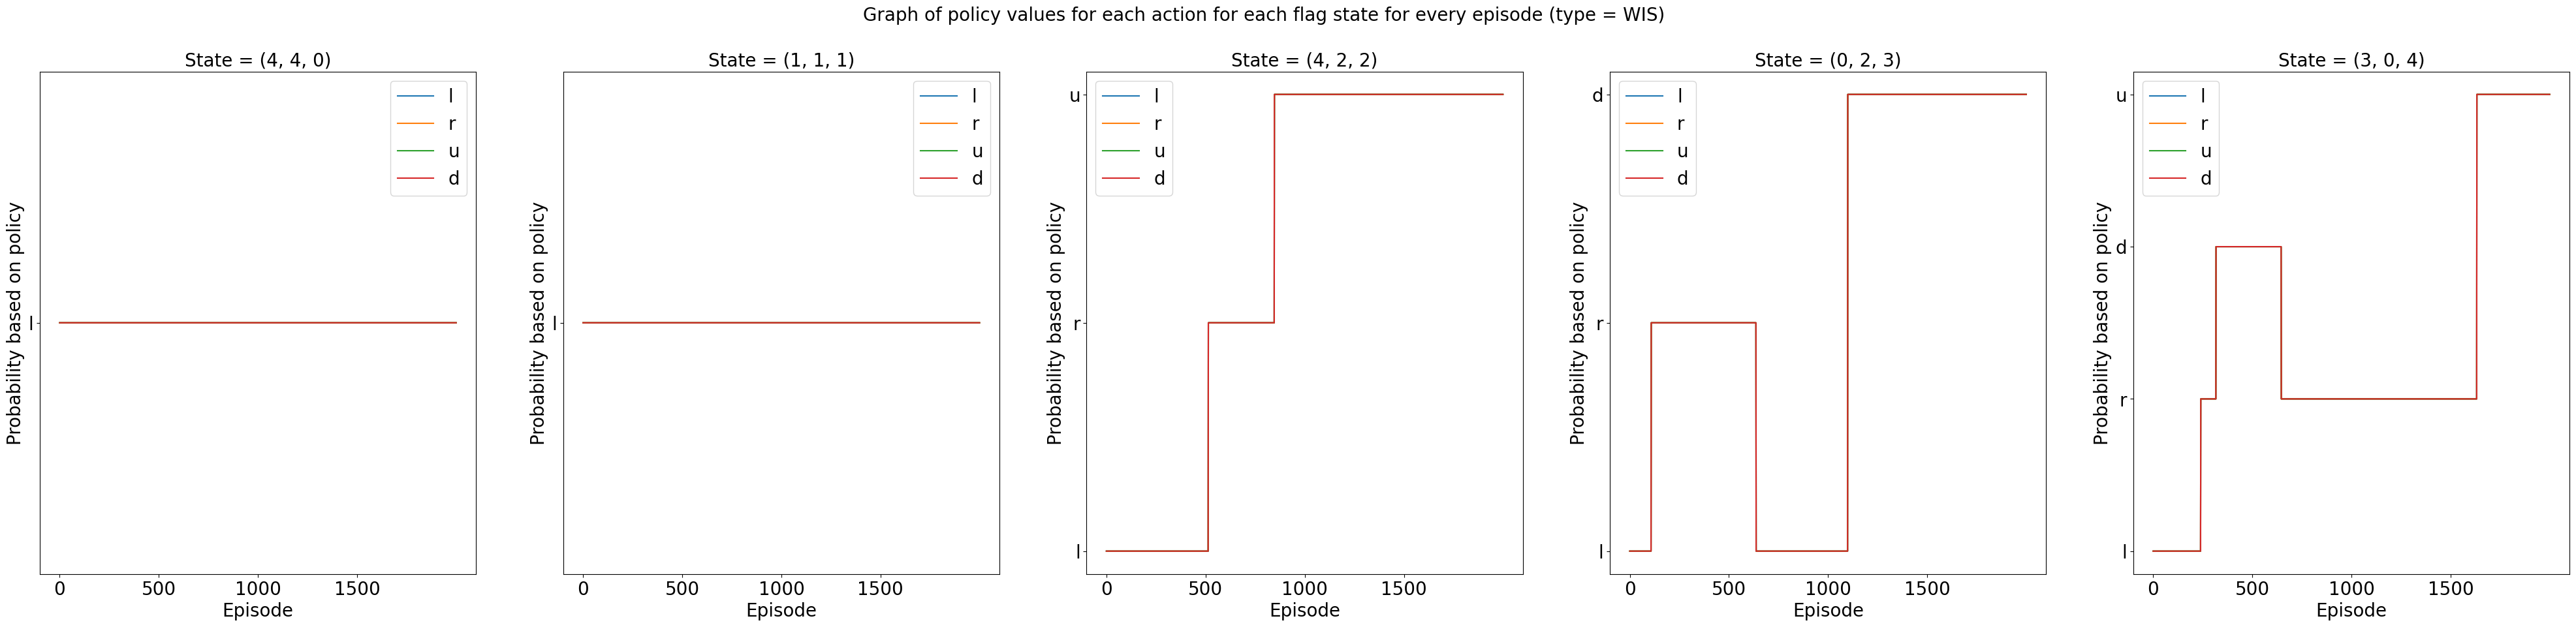

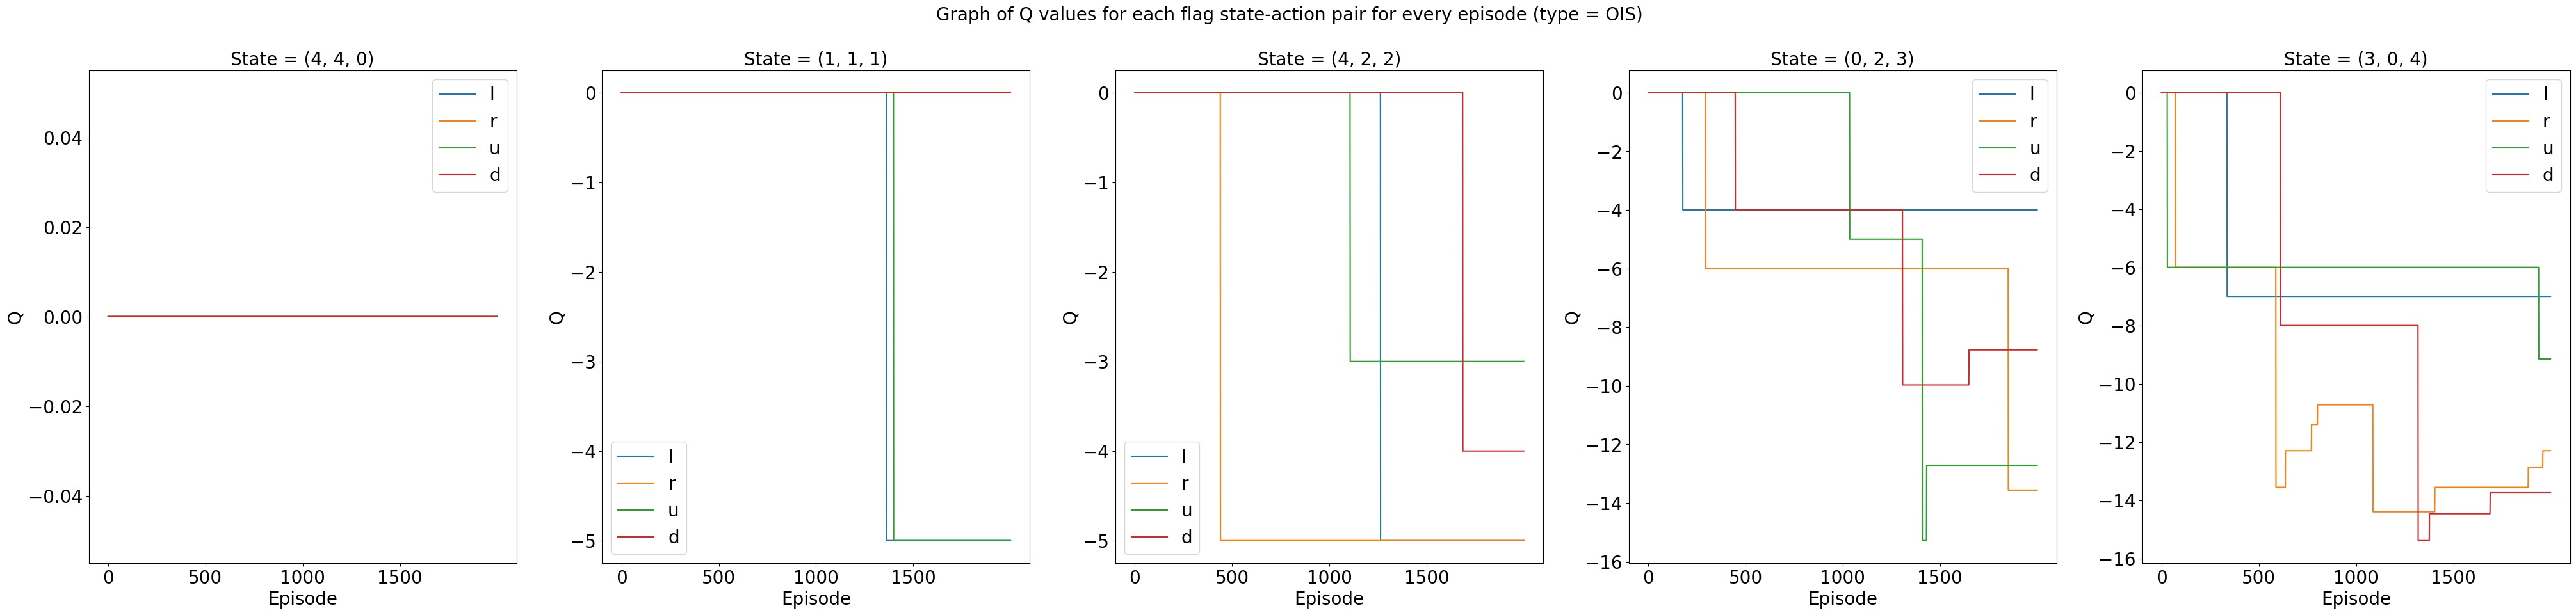

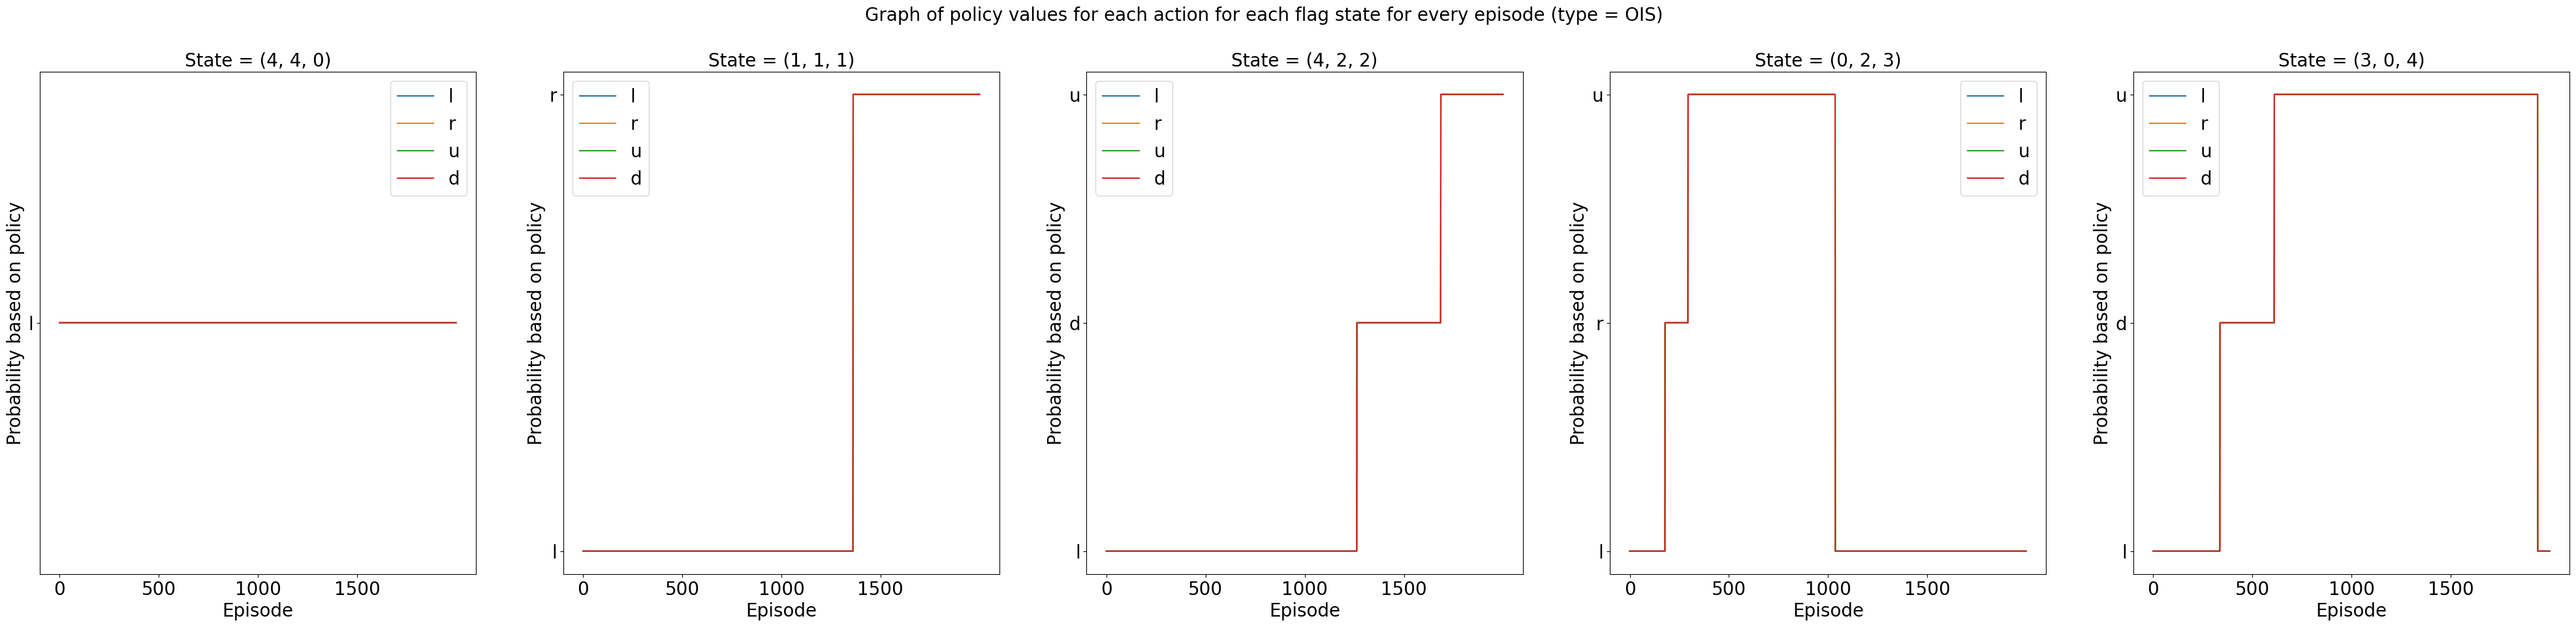

In [13]:
env = Flags()

for ratio_type in ("WIS", "OIS"):
    pi, q = off_policy_mc(ratio_type, env)
    print(f"Type = {ratio_type}")
    print(f"Policy: {pi}")
    print(f"Q: {q}")
    follow_policy(env, pi, off_policy=True)
    print()
    

What is the best epsilon and why?
For each epsilon, did it converge at all? -> talk about the distribution of pi for each state
What was the pi/v for each state after 2000 episodes? (pretty print)
Describe if each correspond to an optimal policy



### 4 Temporal Diference Control Methods [25 Marks]

In this section, you are asked to implement SARSA and Q-learning methods to solve the flags domain. Use a discount factor of $\gamma= 0.99$ and a learning rate of $\alpha = 0.3$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point.Training should proceed for a total of 500 episodes.

4.1. Implement the off-policy Q-learning algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2. [13 Marks]

In [29]:
def create_plots_TD(env, q_history, policy_history, epsilon, save_plots=False):
    """
    Plot Q-values and policy evolution over episodes with enhanced formatting.

    Args:
        env: The environment
        q_history: History of Q-values
        policy_history: History of policy values
        epsilon: Exploration parameter
        save_plots: Whether to save plots to files (default: False)
    """

    # Set style for better visuals
    plt.style.use("seaborn-v0_8-whitegrid")

    # Plot Q-value evolution
    fig1, axes1 = plt.subplots(1, 5, figsize=(20, 6), sharey=True)
    fig1.suptitle(f"Q-values Evolution (ε = {epsilon})", fontsize=16)
    fig1.tight_layout(pad=3.0)

    # Color cycle for better action differentiation
    colors = plt.cm.tab10.colors

    for i, state in enumerate(q_history.keys()):
        for j, action in enumerate(q_history[state]):
            axes1[i].plot(
                range(len(q_history[state][action])),
                q_history[state][action],
                label=f"Action: {action}",
                color=colors[j % len(colors)],
                linewidth=2,
            )
        axes1[i].set_xlabel("Episode", fontsize=12)
        if i == 0:  # Only set y-label on the first subplot
            axes1[i].set_ylabel("Q-value", fontsize=12)
        axes1[i].set_title(f"State {state}", fontsize=12)
        axes1[i].legend(fontsize=10)
        axes1[i].grid(True, alpha=0.3)

    # Plot policy evolution
    fig2, axes2 = plt.subplots(1, 5, figsize=(20, 6), sharey=True)
    fig2.suptitle(f"Policy Evolution (ε = {epsilon})", fontsize=16)
    fig2.tight_layout(pad=3.0)

    for i, state in enumerate(policy_history.keys()):
        for j, action in enumerate(policy_history[state]):
            axes2[i].plot(
                range(len(policy_history[state][action])),
                policy_history[state][action],
                label=f"Action: {action}",
                color=colors[j % len(colors)],
                linewidth=2,
            )
        axes2[i].set_xlabel("Episode", fontsize=12)
        if i == 0:  # Only set y-label on the first subplot
            axes2[i].set_ylabel("Action Probability", fontsize=12)
        axes2[i].set_title(f"State {state}", fontsize=12)
        axes2[i].legend(fontsize=10)
        axes2[i].grid(True, alpha=0.3)

    # Save plots if requested
    if save_plots:
        fig1.savefig(f"q_values_epsilon_{epsilon}.png", dpi=300, bbox_inches="tight")
        fig2.savefig(f"policy_epsilon_{epsilon}.png", dpi=300, bbox_inches="tight")

    plt.show()


def follow_policy_TD(env, policy, off_policy=False):
    """
    Follow a policy through the environment and report the path.

    Args:
        env: Environment object
        policy: Policy to follow (dict mapping states to actions or action probabilities)
        off_policy: Whether the policy is deterministic (True) or stochastic (False)

    Returns:
        Path length and whether goal was reached
    """
    curr_state = env.init_state
    goal_state = env.goal_state
    path = [curr_state]

    print("\n=== PATH TRACING ===")
    print(f"Starting from state: {curr_state}")
    print(f"Target goal state: {goal_state}")

    while curr_state != goal_state:
        # Select action based on policy type
        if off_policy:
            # Deterministic policy (direct action)
            best_action = policy[curr_state]
        else:
            # Stochastic policy (probability distribution over actions)
            action_probs = policy[curr_state]
            # Find action(s) with maximum probability
            max_prob = max(action_probs.values())
            best_actions = [
                a for a, p in action_probs.items() if abs(p - max_prob) < 1e-6
            ]
            best_action = best_actions[0]  # Take the first best action

        # Execute action
        next_state, reward = env.transition(curr_state, best_action)

        # Detect cycles
        if next_state in path:
            print(f"\n⚠️ Cycle detected! Revisiting state: {next_state}")
            break

        # Move to next state and record
        curr_state = next_state
        path.append(curr_state)

    # Print results
    path_length = len(path) - 1  # Number of steps (transitions)

    print("\n=== RESULTS ===")
    print(f"Path length: {path_length} steps")
    print("Path taken:")
    for i, state in enumerate(path):
        if i < len(path) - 1:
            print(f"  {i}: {state} →")
        else:
            print(f"  {i}: {state}")

    if curr_state == goal_state:
        print("\n✅ GOAL REACHED SUCCESSFULLY!")
    else:
        print("\n❌ Failed to reach goal. Possible cycle in policy.")

    return path_length, curr_state == goal_state

In [30]:
class QLearningAgent:
    def __init__(self, env, alpha=0.3, gamma=0.99, epsilon=0.1, episodes=500, max_steps=200):
        self.env = env
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration probability
        self.episodes = episodes
        self.max_steps = max_steps
        self.q_table = {state: {action: 0.0 for action in env.actions_space(state)} for state in env.states_space()}

        # Track Q-value progression for specific states
        self.q_history = {state: {action: [] for action in env.actions_space(state)} 
                          for state in [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]}
        
        # Track best policy choice for specific states
        self.policy_history = {state: {action: [] for action in env.actions_space(state)} 
                               for state in [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]}
        
    def get_action_probabilities(self, state):
        """
        Return probability distribution over actions for given state
        based on epsilon-greedy policy
        """
        # Get number of possible actions for this state
        actions = self.env.actions_space(state)
        n_actions = len(actions)

        # Initialize probabilities with the exploration probability
        probs = {a: self.epsilon / n_actions for a in actions}

        # Find action(s) with maximum Q-value
        max_q_value = max(self.q_table[state].values())
        best_actions = [a for a, q in self.q_table[state].items() if q == max_q_value]

        # Distribute the exploitation probability (1-epsilon) among best actions
        for action in best_actions:
            probs[action] += (1.0 - self.epsilon) / len(best_actions)

        return probs

    def choose_action(self, state):
        """Select action using epsilon-greedy policy"""
        action_probs = self.get_action_probabilities(state)

        # Convert to list for sampling
        actions = list(action_probs.keys())
        probs = list(action_probs.values())

        # Choose action based on probability distribution
        return random.choices(actions, weights=probs)[0]
    
    def train(self):
        for episode in range(self.episodes):
            state = self.env.reset()
            for step in range(self.max_steps):
                action = self.choose_action(state)
                next_state, reward = self.env.transition(state, action)
                
                # Q-value update
                best_next_action = max(self.q_table[next_state], key=self.q_table[next_state].get)
                self.q_table[state][action] += self.alpha * (reward + self.gamma * self.q_table[next_state][best_next_action] - self.q_table[state][action])
                
                state = next_state
                if state == self.env.goal_state:
                    break # end episode if goal reached

            for s in self.q_history.keys():
                for a in self.q_history[s].keys():
                    self.q_history[s][a].append(self.q_table[s][a])  # Track Q-value change
                    best_action = max(self.q_table[s], key=self.q_table[s].get)
                    self.policy_history[s][a].append(1 if a == best_action else 0)  # 1 if best action, 0 otherwise

    def get_policy(self):
        """Return the policy as probability distributions over actions for each state"""
        policy = {}
        for state in self.q_table:
            policy[state] = self.get_action_probabilities(state)
        return policy



Epsilon = 0.01

=== PATH TRACING ===
Starting from state: (4, 4, 0)
Target goal state: (0, 4, 4)

=== RESULTS ===
Path length: 26 steps
Path taken:
  0: (4, 4, 0) →
  1: (3, 4, 0) →
  2: (2, 4, 0) →
  3: (2, 3, 0) →
  4: (1, 3, 0) →
  5: (1, 2, 0) →
  6: (1, 1, 1) →
  7: (1, 2, 1) →
  8: (2, 2, 1) →
  9: (3, 2, 1) →
  10: (4, 2, 2) →
  11: (3, 2, 2) →
  12: (2, 2, 2) →
  13: (1, 2, 2) →
  14: (0, 2, 3) →
  15: (1, 2, 3) →
  16: (2, 2, 3) →
  17: (2, 1, 3) →
  18: (2, 0, 3) →
  19: (3, 0, 4) →
  20: (3, 1, 4) →
  21: (3, 2, 4) →
  22: (3, 3, 4) →
  23: (2, 3, 4) →
  24: (2, 4, 4) →
  25: (1, 4, 4) →
  26: (0, 4, 4)

✅ GOAL REACHED SUCCESSFULLY!


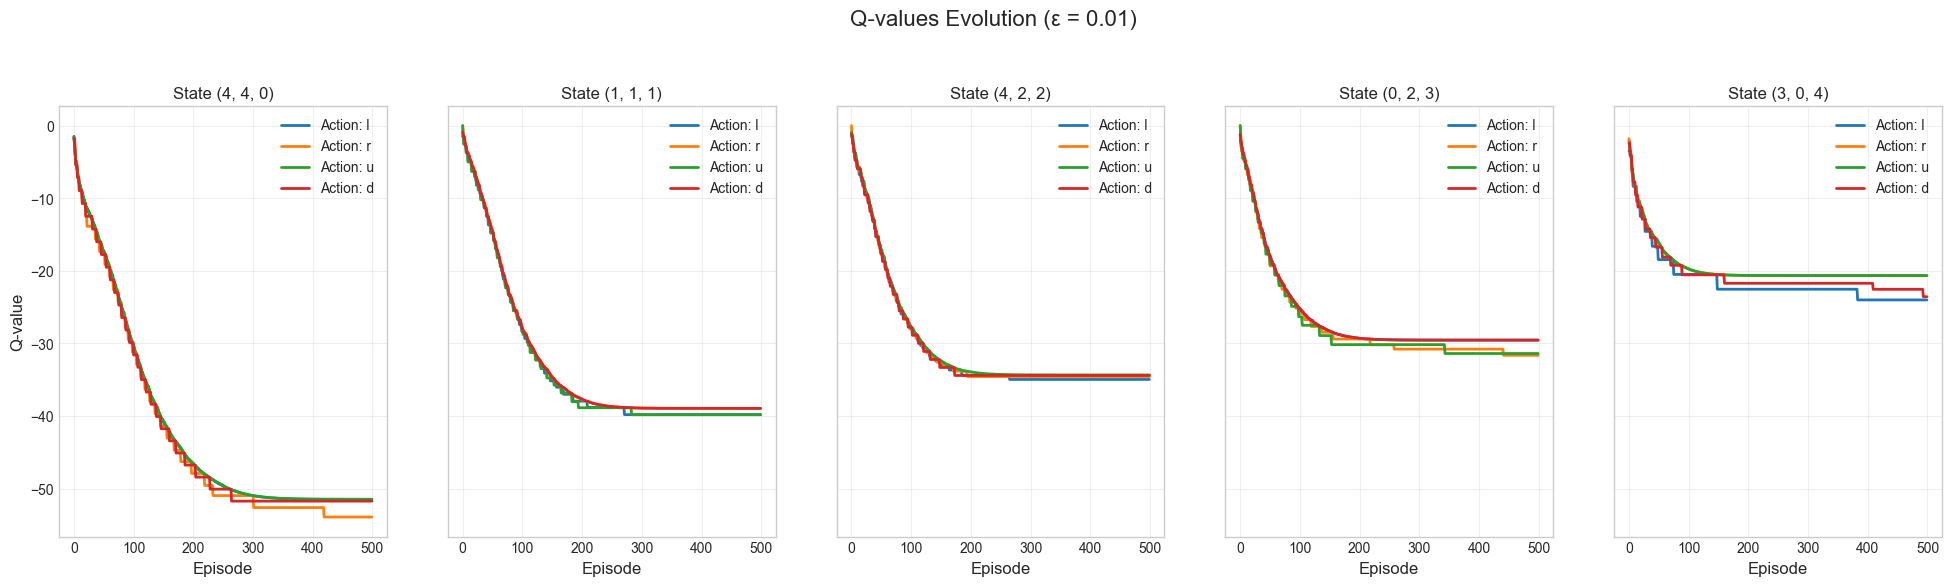

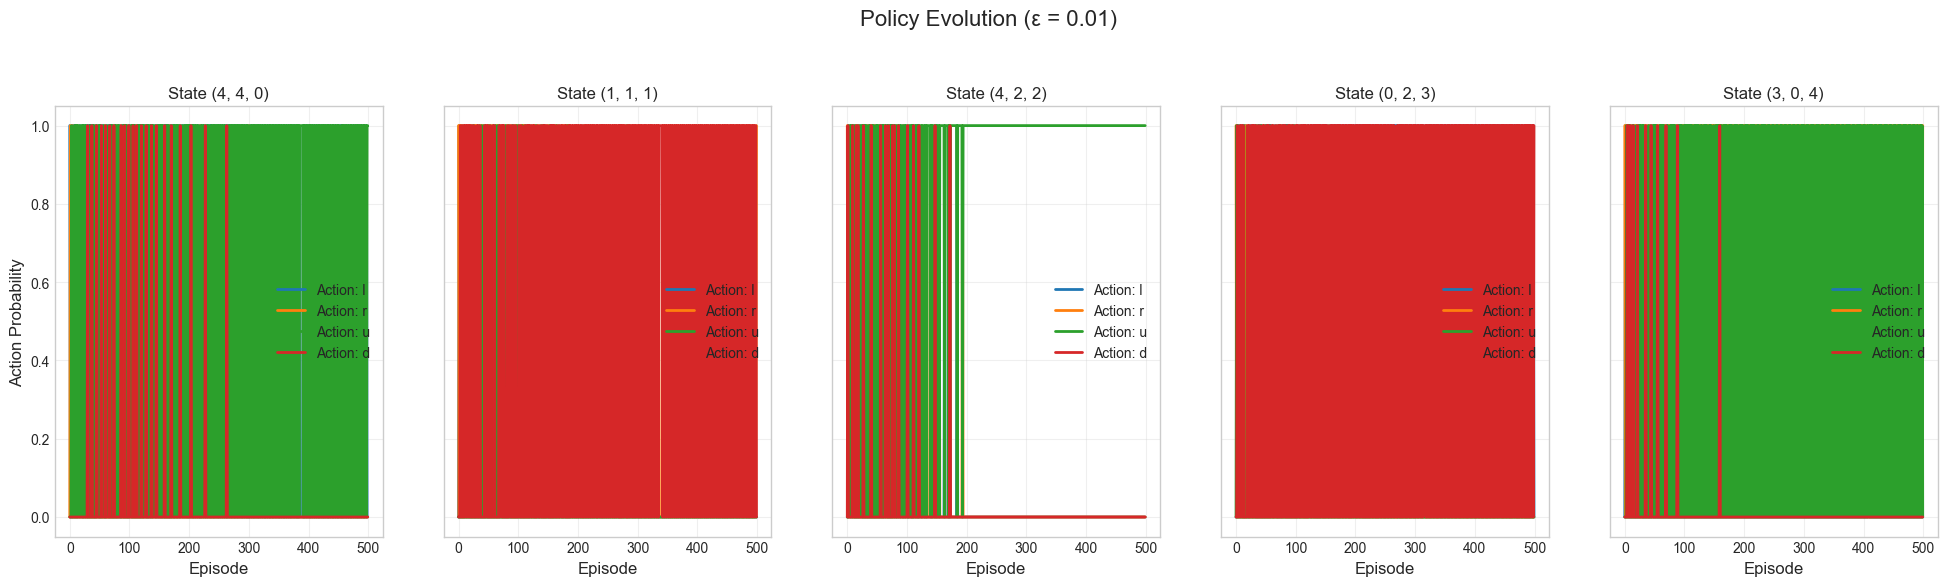

Epsilon = 0.1

=== PATH TRACING ===
Starting from state: (4, 4, 0)
Target goal state: (0, 4, 4)

=== RESULTS ===
Path length: 26 steps
Path taken:
  0: (4, 4, 0) →
  1: (4, 3, 0) →
  2: (3, 3, 0) →
  3: (3, 2, 0) →
  4: (3, 1, 0) →
  5: (2, 1, 0) →
  6: (1, 1, 1) →
  7: (1, 2, 1) →
  8: (2, 2, 1) →
  9: (3, 2, 1) →
  10: (4, 2, 2) →
  11: (3, 2, 2) →
  12: (2, 2, 2) →
  13: (1, 2, 2) →
  14: (0, 2, 3) →
  15: (0, 1, 3) →
  16: (0, 0, 3) →
  17: (1, 0, 3) →
  18: (2, 0, 3) →
  19: (3, 0, 4) →
  20: (2, 0, 4) →
  21: (1, 0, 4) →
  22: (0, 0, 4) →
  23: (0, 1, 4) →
  24: (0, 2, 4) →
  25: (0, 3, 4) →
  26: (0, 4, 4)

✅ GOAL REACHED SUCCESSFULLY!


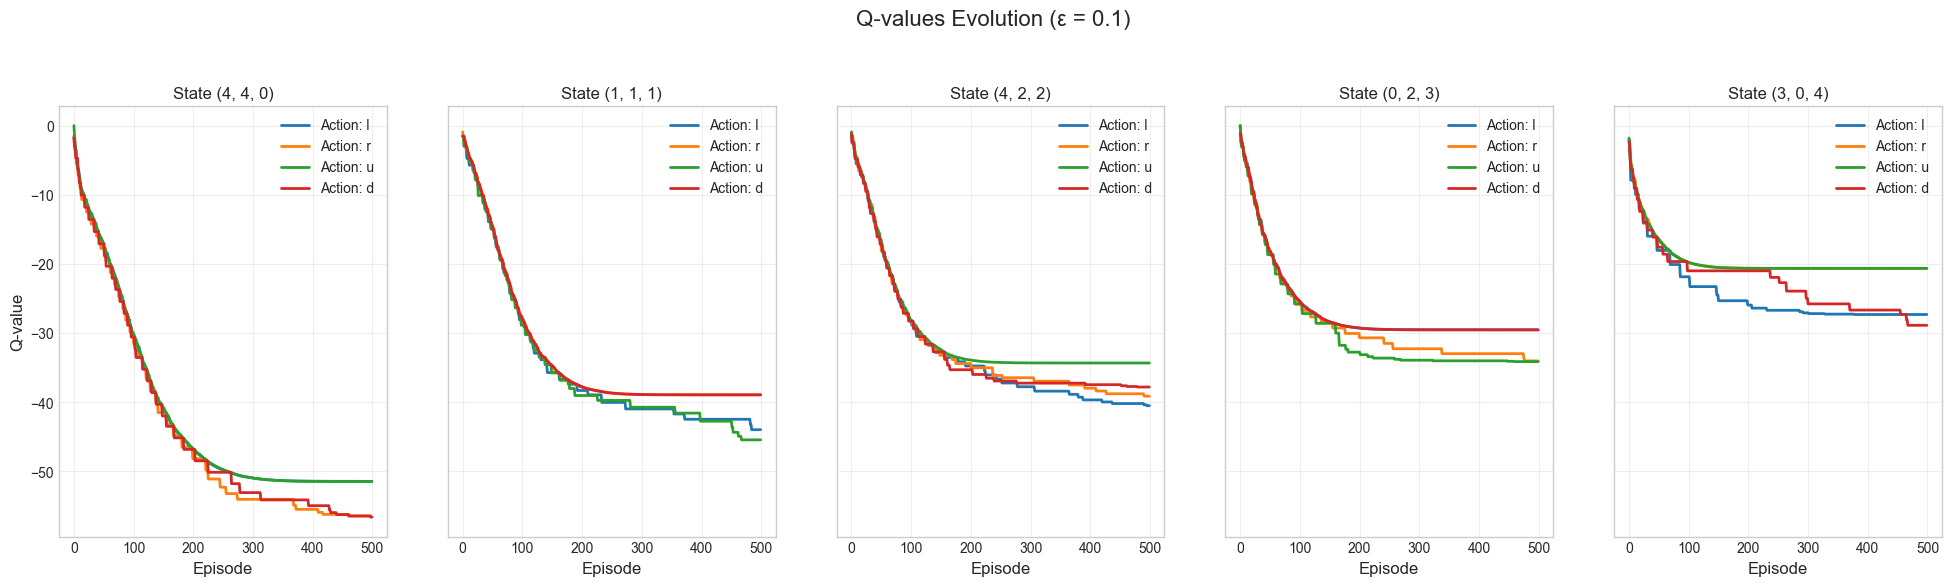

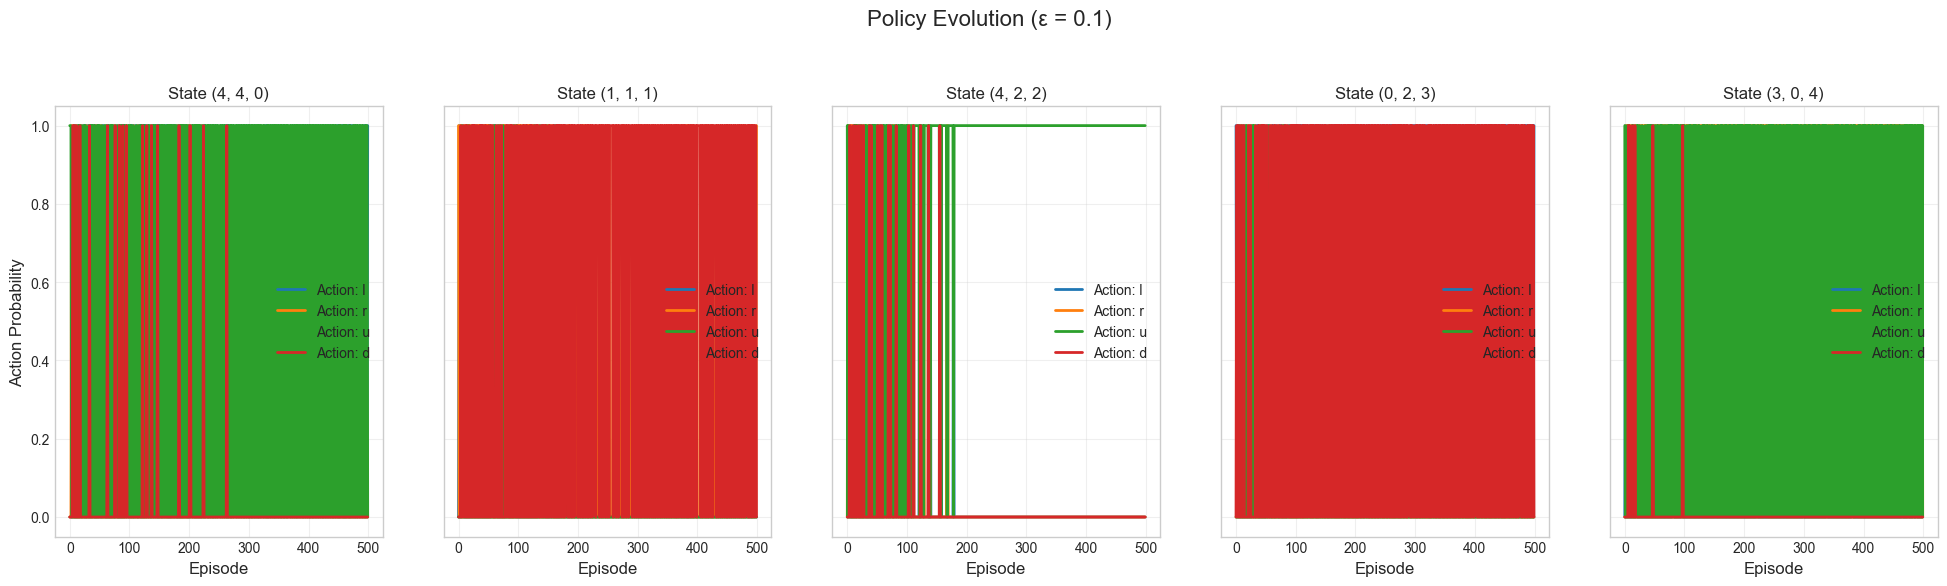

Epsilon = 0.25

=== PATH TRACING ===
Starting from state: (4, 4, 0)
Target goal state: (0, 4, 4)

=== RESULTS ===
Path length: 26 steps
Path taken:
  0: (4, 4, 0) →
  1: (4, 3, 0) →
  2: (3, 3, 0) →
  3: (2, 3, 0) →
  4: (2, 2, 0) →
  5: (2, 1, 0) →
  6: (1, 1, 1) →
  7: (2, 1, 1) →
  8: (3, 1, 1) →
  9: (4, 1, 1) →
  10: (4, 2, 2) →
  11: (3, 2, 2) →
  12: (2, 2, 2) →
  13: (1, 2, 2) →
  14: (0, 2, 3) →
  15: (0, 1, 3) →
  16: (1, 1, 3) →
  17: (1, 0, 3) →
  18: (2, 0, 3) →
  19: (3, 0, 4) →
  20: (3, 1, 4) →
  21: (2, 1, 4) →
  22: (2, 2, 4) →
  23: (2, 3, 4) →
  24: (2, 4, 4) →
  25: (1, 4, 4) →
  26: (0, 4, 4)

✅ GOAL REACHED SUCCESSFULLY!


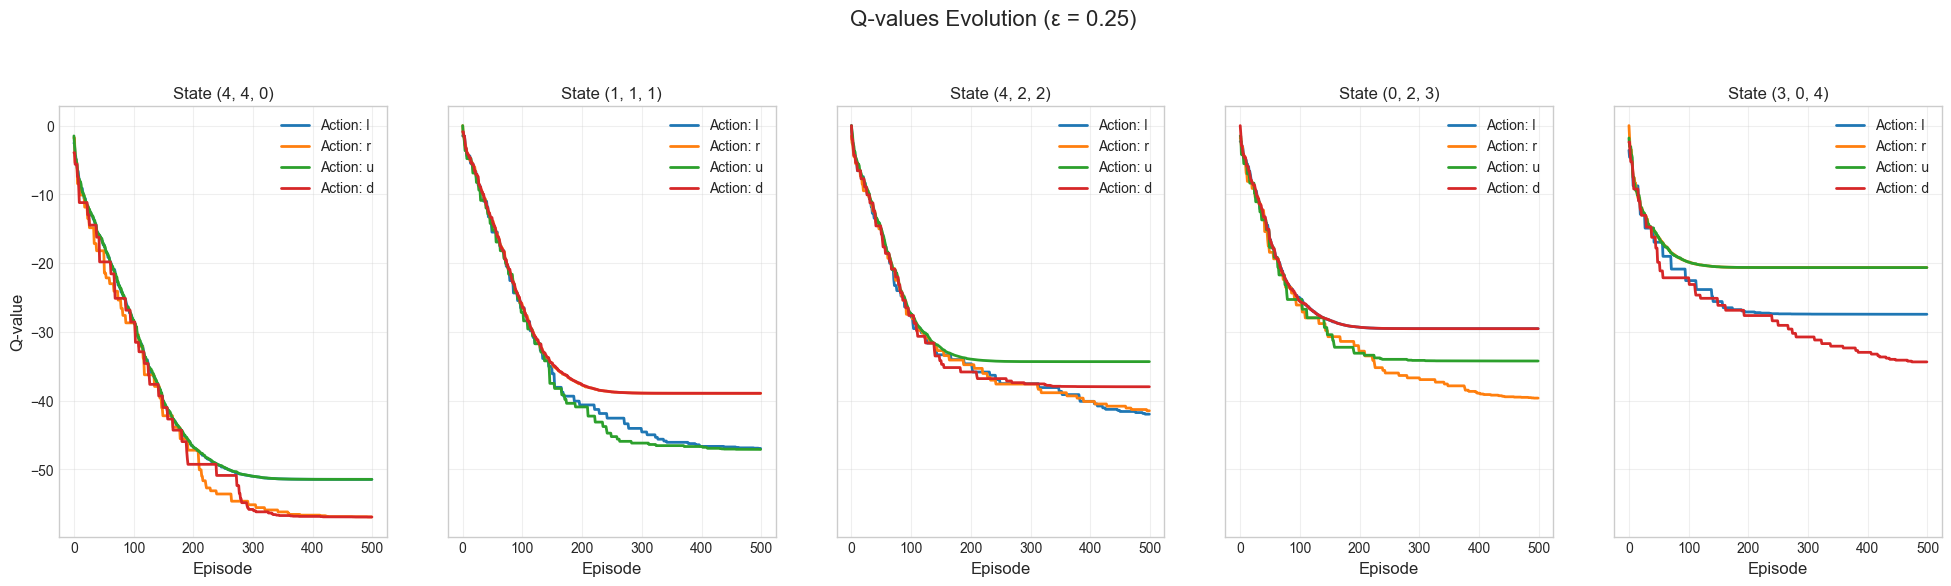

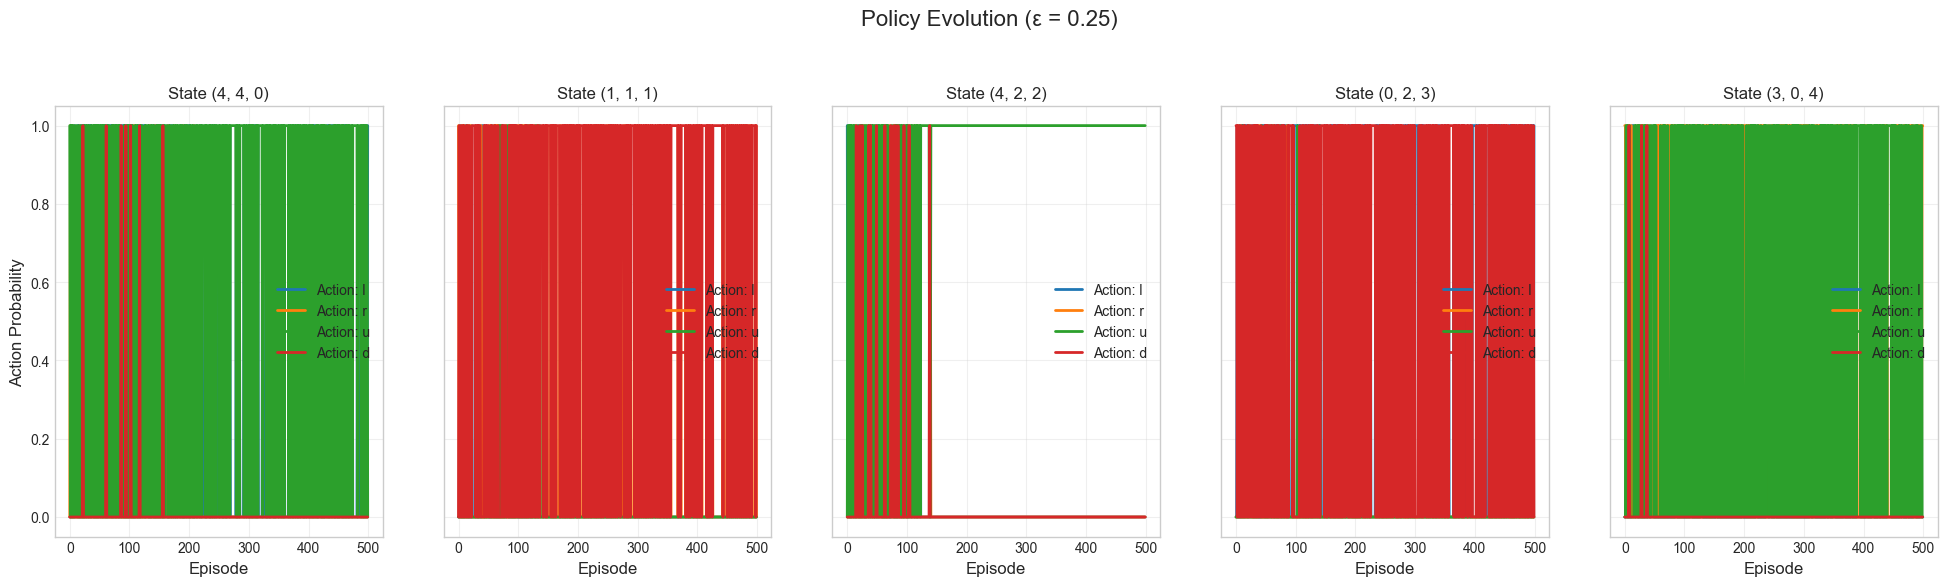

In [31]:
for epsilon in (0.01, 0.1, 0.25):
    env = Flags()
    q_learning = QLearningAgent(env, epsilon=epsilon)
    q_learning.train()
    policy = q_learning.get_policy()
    print(f"Epsilon = {epsilon}")
    follow_policy_TD(env, policy)
    create_plots_TD(env, q_learning.q_history, q_learning.policy_history, q_learning.epsilon)
    

4.2. Implement on-policy one-step Sarsa algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2.[12 Marks]

In [32]:
class SarsaAgent:
    def __init__(
        self, env, alpha=0.3, gamma=0.99, epsilon=0.1, episodes=5000, max_steps=200
    ):
        self.env = env
        self.alpha = alpha  # learning rate
        self.gamma = gamma  # discount factor
        self.epsilon = epsilon  # exploration probability
        self.episodes = episodes
        self.max_steps = max_steps

        # Initialize Q-values for all state-action pairs to 0
        self.q_table = {
            state: {action: 0.0 for action in env.actions_space(state)}
            for state in env.states_space()
        }

        # For monitoring: choose a few states of interest (initial and post-flag states)
        self.monitoring_states = [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]

        # To record the evolution of Q-values and best-policy choices for plotting
        self.q_history = {
            state: {action: [] for action in env.actions_space(state)}
            for state in self.monitoring_states
        }
        self.policy_history = {
            state: {action: [] for action in env.actions_space(state)}
            for state in self.monitoring_states
        }

    def get_action_probabilities(self, state):
        """
        Return probability distribution over actions for given state
        based on epsilon-greedy policy
        """
        # Get number of possible actions for this state
        actions = self.env.actions_space(state)
        n_actions = len(actions)

        # Initialize probabilities with the exploration probability
        probs = {a: self.epsilon / n_actions for a in actions}

        # Find action(s) with maximum Q-value
        max_q_value = max(self.q_table[state].values())
        best_actions = [a for a, q in self.q_table[state].items() if q == max_q_value]

        # Distribute the exploitation probability (1-epsilon) among best actions
        for action in best_actions:
            probs[action] += (1.0 - self.epsilon) / len(best_actions)

        return probs

    def choose_action(self, state):
        """Select action using epsilon-greedy policy"""
        action_probs = self.get_action_probabilities(state)

        # Convert to list for sampling
        actions = list(action_probs.keys())
        probs = list(action_probs.values())

        # Choose action based on probability distribution using standard random module
        return random.choices(actions, weights=probs, k=1)[0]

    def train(self):
        """Train the agent using one-step Sarsa algorithm"""
        for episode in range(self.episodes):
            state = self.env.reset()
            # Choose A from S using policy derived from Q (epsilon-greedy)
            action = self.choose_action(state)

            for step in range(self.max_steps):
                # Take action A, observe R, S'
                next_state, reward = self.env.transition(state, action)

                # Choose A' from S' using policy derived from Q (epsilon-greedy)
                next_action = self.choose_action(next_state)

                # Update Q(S,A) towards target: R + γQ(S',A')
                self.q_table[state][action] += self.alpha * (
                    reward
                    + self.gamma * self.q_table[next_state][next_action]
                    - self.q_table[state][action]
                )

                # S ← S', A ← A'
                state, action = next_state, next_action

                # Break if terminal state reached
                if state == self.env.goal_state:
                    break

            # Record monitoring information for selected states
            for s in self.monitoring_states:
                for a in self.env.actions_space(s):
                    self.q_history[s][a].append(self.q_table[s][a])

                # Get policy probabilities for this state
                action_probs = self.get_action_probabilities(s)
                for a in self.env.actions_space(s):
                    self.policy_history[s][a].append(action_probs[a])

    def get_policy(self):
        """Return the policy as probability distributions over actions for each state"""
        policy = {}
        for state in self.q_table:
            policy[state] = self.get_action_probabilities(state)
        return policy

    def get_greedy_policy(self):
        """Return a deterministic greedy policy (for evaluation)"""
        greedy_policy = {}
        for state in self.q_table:
            max_q_value = max(self.q_table[state].values())
            best_actions = [
                a for a, q in self.q_table[state].items() if q == max_q_value
            ]
            # Randomly select among best actions (in case of ties)
            greedy_policy[state] = random.choice(best_actions)
        return greedy_policy

Epsilon = 0.01

=== PATH TRACING ===
Starting from state: (4, 4, 0)
Target goal state: (0, 4, 4)

=== RESULTS ===
Path length: 26 steps
Path taken:
  0: (4, 4, 0) →
  1: (4, 3, 0) →
  2: (3, 3, 0) →
  3: (2, 3, 0) →
  4: (2, 2, 0) →
  5: (2, 1, 0) →
  6: (1, 1, 1) →
  7: (2, 1, 1) →
  8: (3, 1, 1) →
  9: (3, 2, 1) →
  10: (4, 2, 2) →
  11: (3, 2, 2) →
  12: (2, 2, 2) →
  13: (1, 2, 2) →
  14: (0, 2, 3) →
  15: (1, 2, 3) →
  16: (1, 1, 3) →
  17: (2, 1, 3) →
  18: (2, 0, 3) →
  19: (3, 0, 4) →
  20: (3, 1, 4) →
  21: (2, 1, 4) →
  22: (2, 2, 4) →
  23: (1, 2, 4) →
  24: (0, 2, 4) →
  25: (0, 3, 4) →
  26: (0, 4, 4)

✅ GOAL REACHED SUCCESSFULLY!


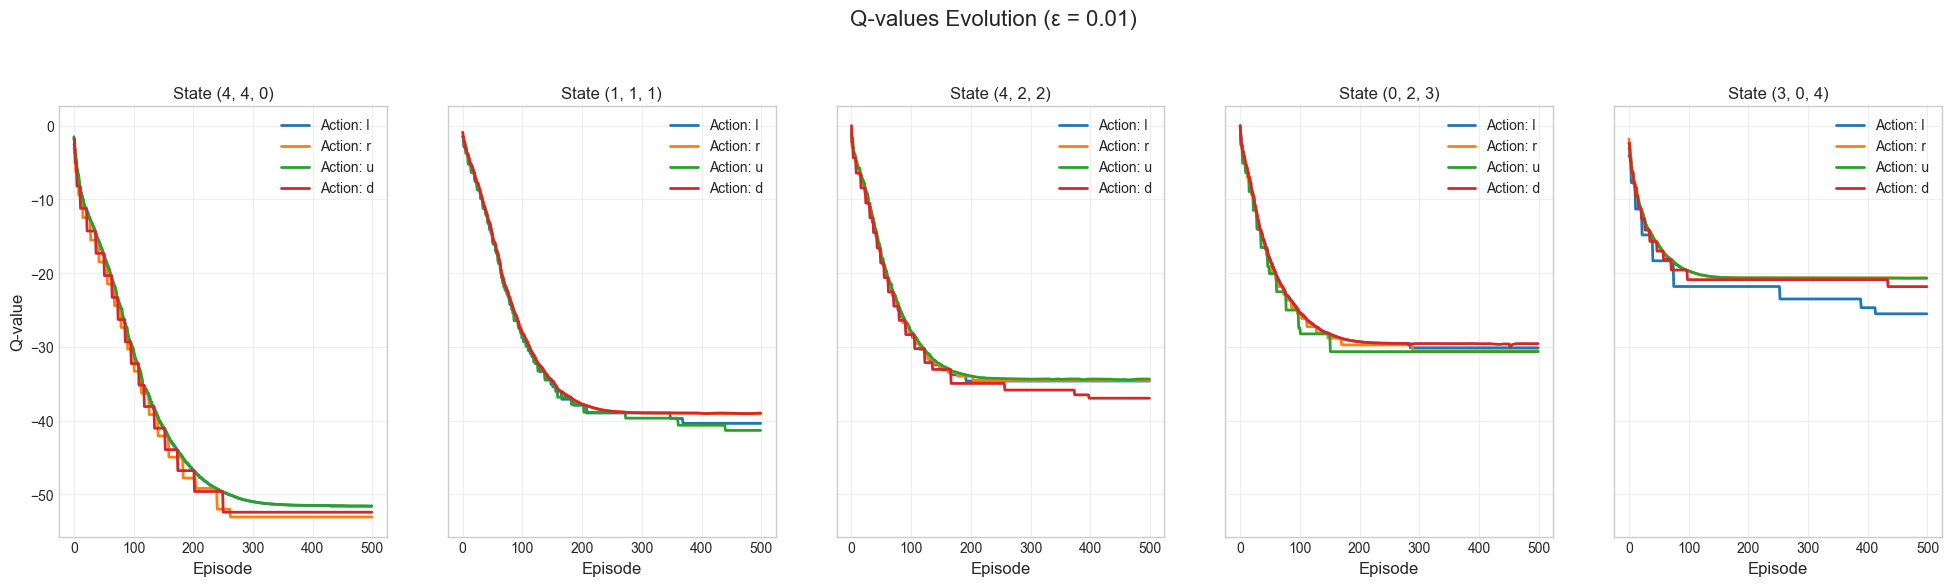

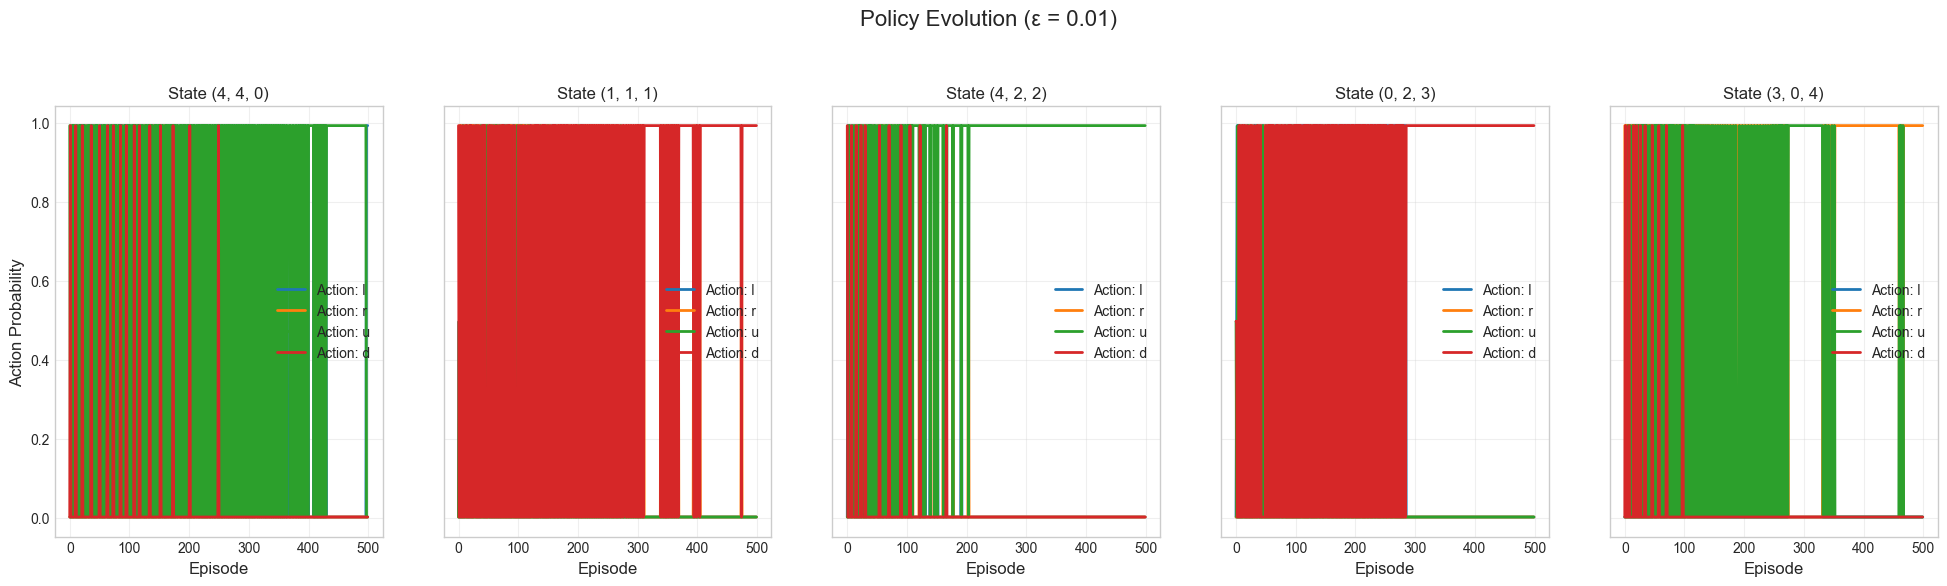

Epsilon = 0.1

=== PATH TRACING ===
Starting from state: (4, 4, 0)
Target goal state: (0, 4, 4)

=== RESULTS ===
Path length: 26 steps
Path taken:
  0: (4, 4, 0) →
  1: (4, 3, 0) →
  2: (3, 3, 0) →
  3: (3, 2, 0) →
  4: (3, 1, 0) →
  5: (2, 1, 0) →
  6: (1, 1, 1) →
  7: (2, 1, 1) →
  8: (2, 2, 1) →
  9: (3, 2, 1) →
  10: (4, 2, 2) →
  11: (3, 2, 2) →
  12: (2, 2, 2) →
  13: (1, 2, 2) →
  14: (0, 2, 3) →
  15: (1, 2, 3) →
  16: (1, 1, 3) →
  17: (2, 1, 3) →
  18: (2, 0, 3) →
  19: (3, 0, 4) →
  20: (2, 0, 4) →
  21: (1, 0, 4) →
  22: (1, 1, 4) →
  23: (1, 2, 4) →
  24: (0, 2, 4) →
  25: (0, 3, 4) →
  26: (0, 4, 4)

✅ GOAL REACHED SUCCESSFULLY!


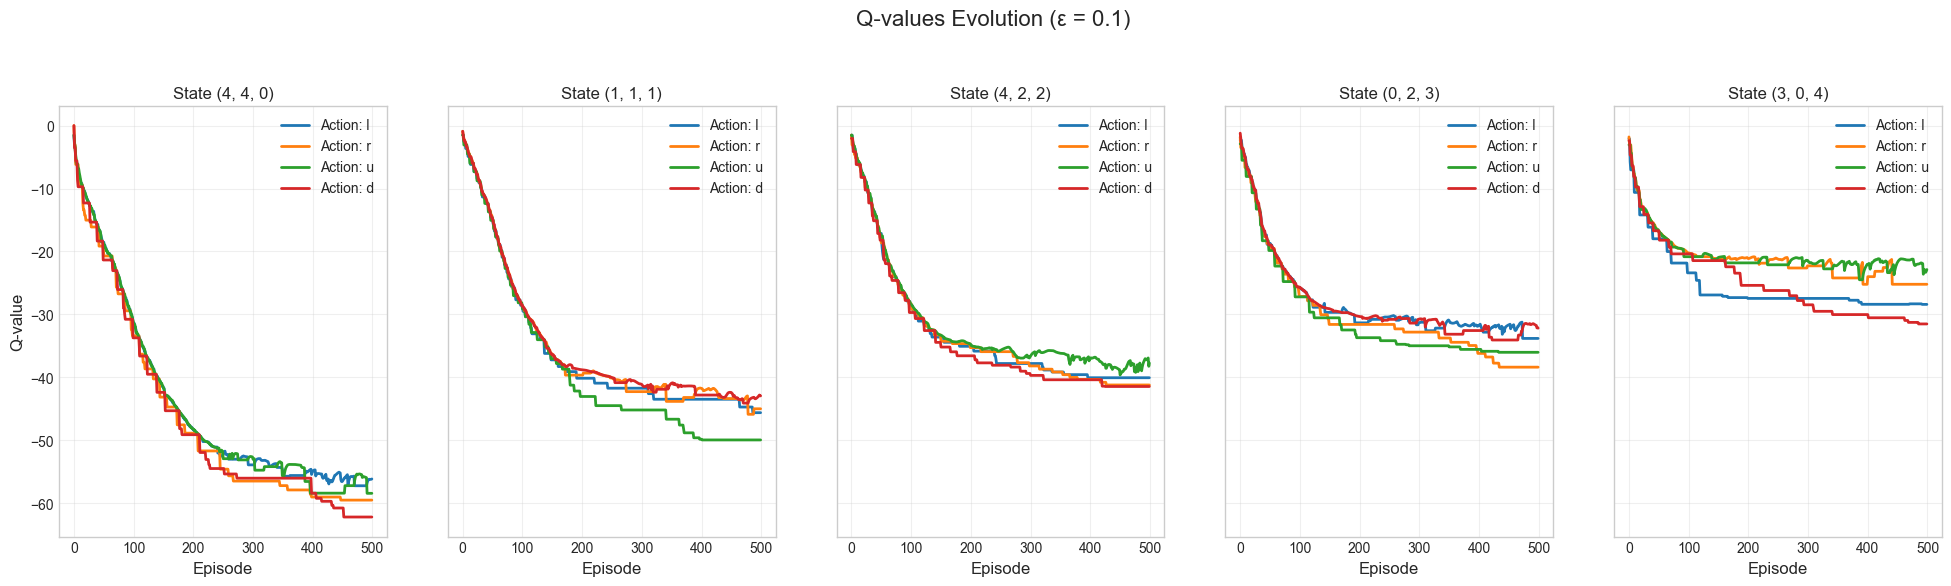

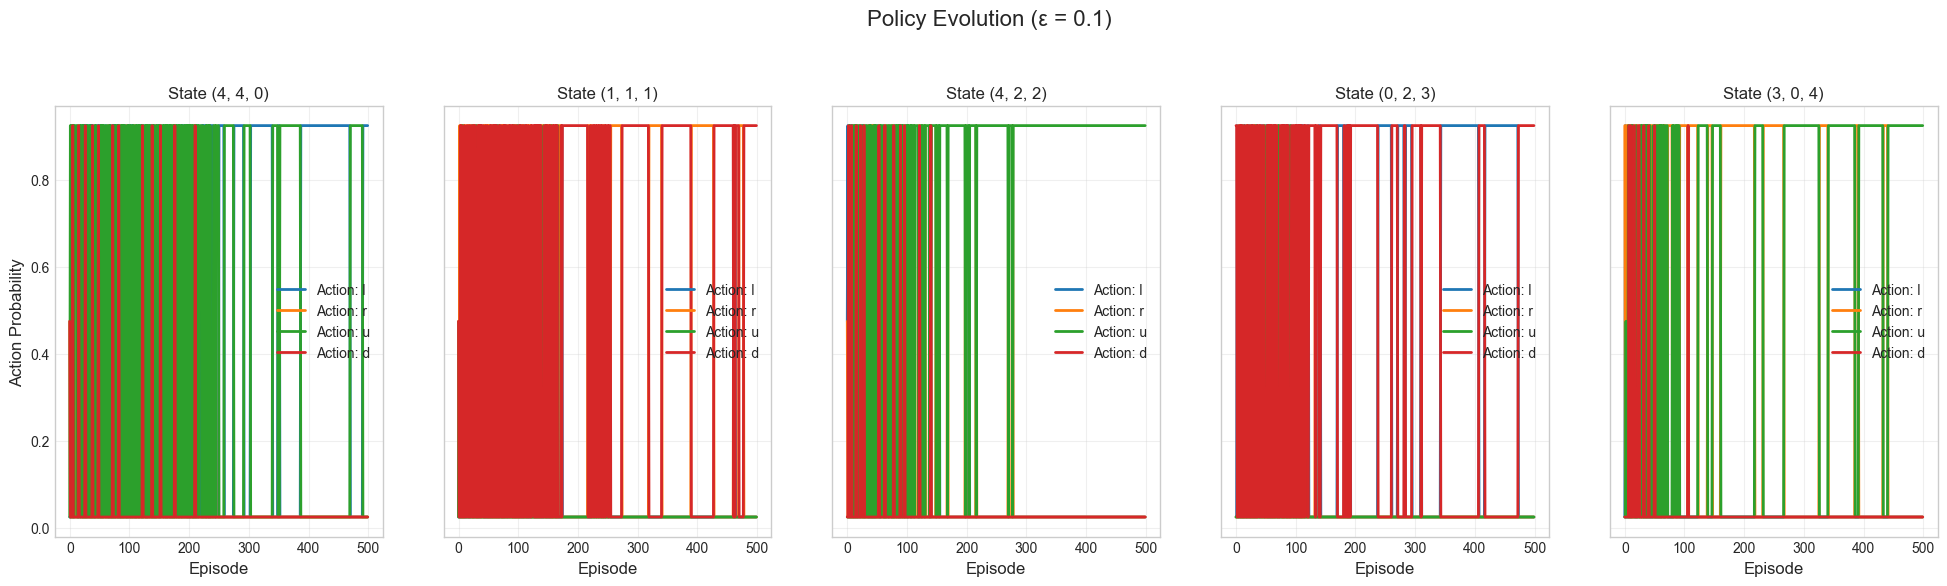

Epsilon = 0.25

=== PATH TRACING ===
Starting from state: (4, 4, 0)
Target goal state: (0, 4, 4)

=== RESULTS ===
Path length: 26 steps
Path taken:
  0: (4, 4, 0) →
  1: (3, 4, 0) →
  2: (2, 4, 0) →
  3: (1, 4, 0) →
  4: (1, 3, 0) →
  5: (1, 2, 0) →
  6: (1, 1, 1) →
  7: (2, 1, 1) →
  8: (2, 2, 1) →
  9: (3, 2, 1) →
  10: (4, 2, 2) →
  11: (3, 2, 2) →
  12: (2, 2, 2) →
  13: (1, 2, 2) →
  14: (0, 2, 3) →
  15: (0, 1, 3) →
  16: (0, 0, 3) →
  17: (1, 0, 3) →
  18: (2, 0, 3) →
  19: (3, 0, 4) →
  20: (2, 0, 4) →
  21: (1, 0, 4) →
  22: (1, 1, 4) →
  23: (0, 1, 4) →
  24: (0, 2, 4) →
  25: (0, 3, 4) →
  26: (0, 4, 4)

✅ GOAL REACHED SUCCESSFULLY!


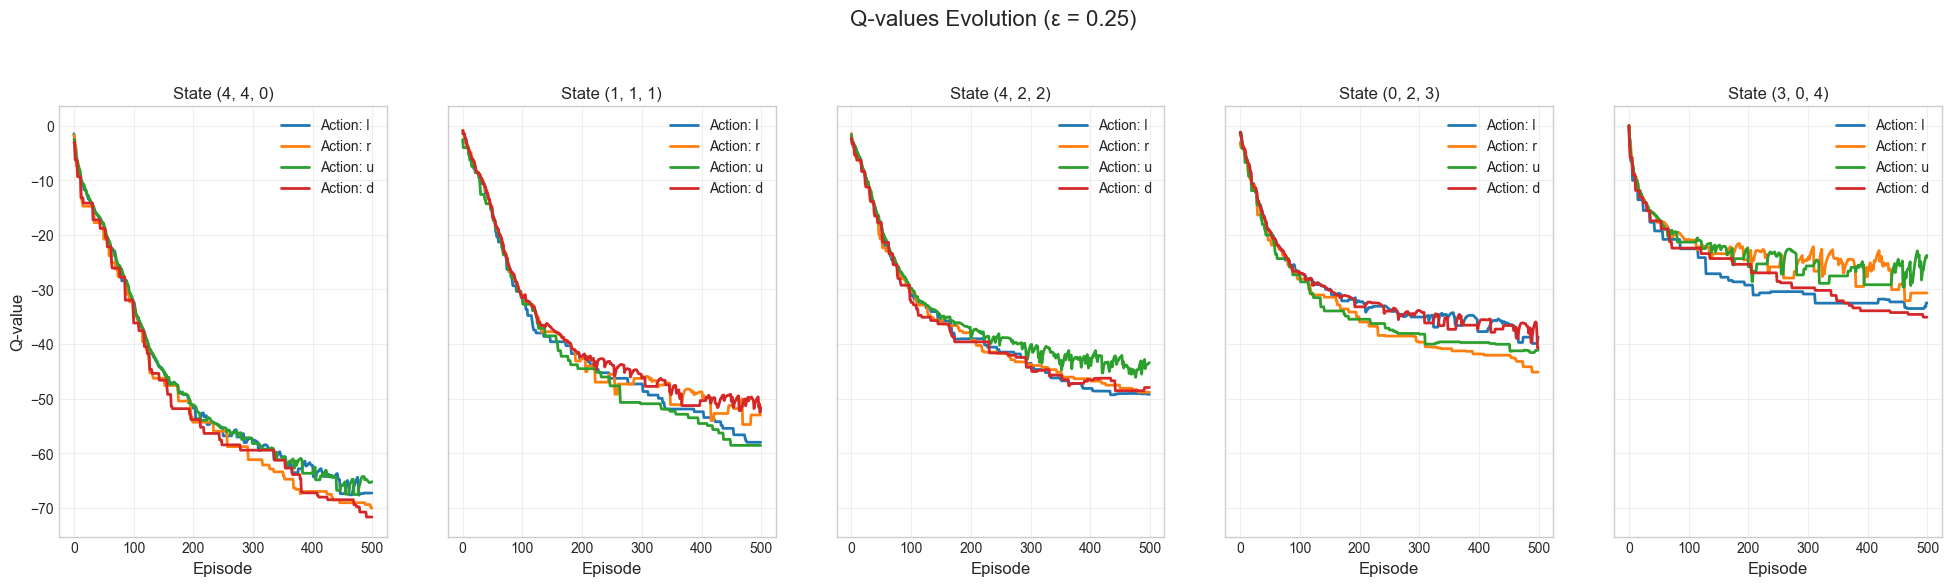

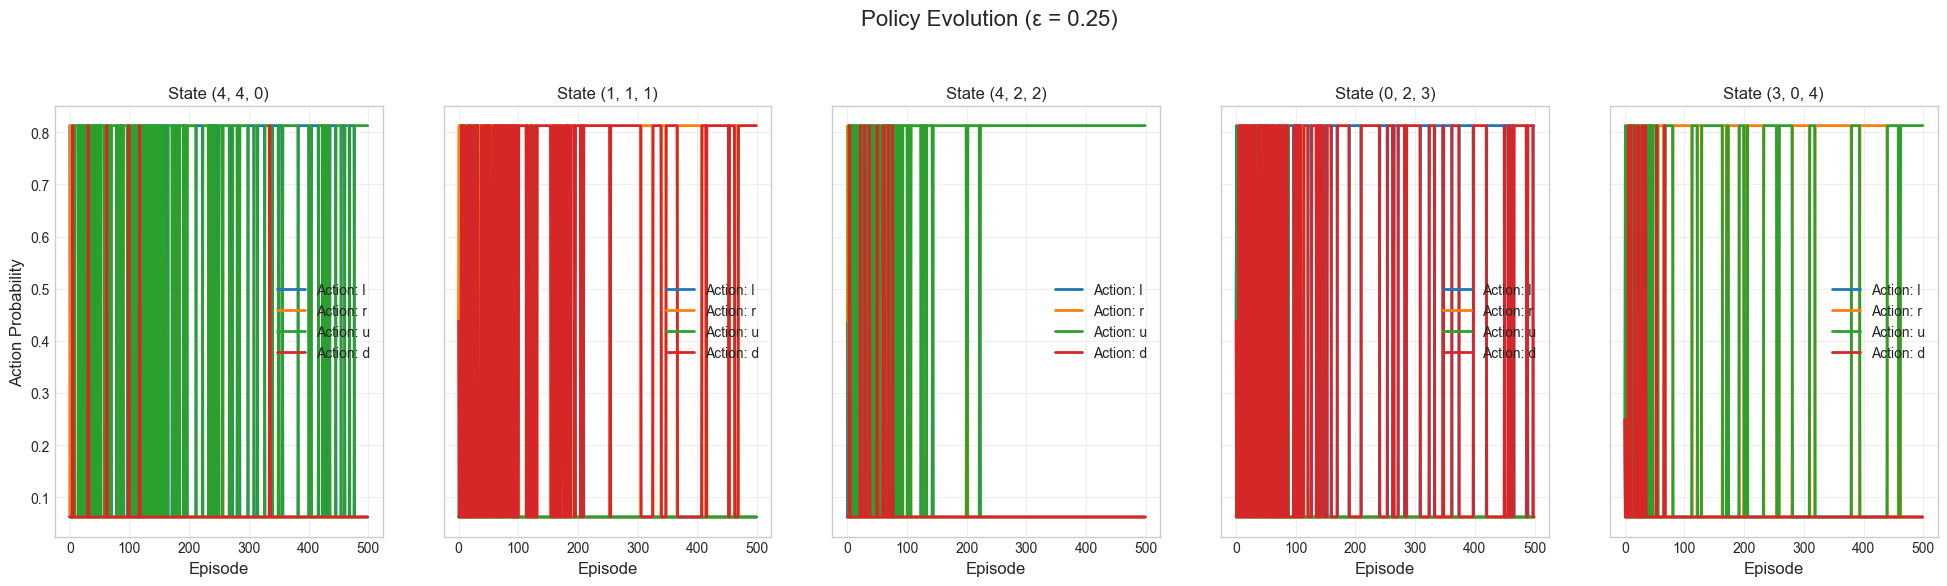

In [33]:
for epsilon in (0.01, 0.1, 0.25):
    env = Flags()
    sarsa_agent = SarsaAgent(env, epsilon=epsilon, episodes=500, max_steps=200)
    sarsa_agent.train()
    policy = sarsa_agent.get_policy()
    print(f"Epsilon = {epsilon}")
    follow_policy_TD(env, policy)
    create_plots_TD(
        env, sarsa_agent.q_history, sarsa_agent.policy_history, sarsa_agent.epsilon
    )

### 5 Comparing Algorithms [25 Marks]

In the final section of your report, you must compare the different control algorithm you implemented on the Flags domain. In particular, please comment on at least the following issues in your report:

(a) Were the Q-value functions and policies you obtained using each algorithm similar? Were they different? Comment on this using the properties of each algorithm you learned in class [6 Marks]

(b) Use the plots you created for each ε to make a detailed comparison of the performance of the algorithms implemented in 3.2, 4.1 and 4.2. Answer the following questions for each ε you tested. Which one converged the fastest on average? Which one the slowest? Which one
had lower variance and which had higher variance? Why? [6 Marks]

(c) choose one particular ε for all three algorithms and one of the importance sampling Monte Carlo control, compare their testing performances of policies learned by all the algorithm (try to visualize this comparison). [13 Marks]

**Part a)**

To simplify the analysis, we analyze the Q-values and policies of the 5 states that were used for graphing, namely: (4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), and (3, 0, 4).

First-Visit Monte Carlo:
- Q((4, 4, 0), ('l'))
- optimal action at (4, 4, 0):

Off-policy Monte Carlo:

Q-Learning:

SARSA:


**Part b)**

Epsilon = 0.01
- which one converged the fastest? Which one the slowest? WHich one had lower variance and which had higher variacnce? Why?


Epsilon = 0.1


Epsilon = 0.25